# Forecasting California Electricity Demand

Emily Mader

---

Electricity demand has to be matched by supply in close to real time, so utilities forecast it constantly. This notebook builds an hourly demand forecast for California from weather and calendar variables, using OLS and a SARIMA model fitted to the OLS residuals.

I set out to answer three questions:

1. Which variables are the strongest predictors of demand?
2. How accurate is the forecast, measured against baselines that require no model at all?
3. How far ahead does the forecast remain useful?

The third question turns out to govern the answer to the second. A forecast made one hour ahead and a forecast made a week ahead are different problems, and a specification that performs well on one can perform poorly on the other. I therefore fix two horizons at the outset and carry both through every stage of the analysis.

<a id="toc"></a>
## Contents

| Section | Contents |
|---|---|
| [Key findings](#findings) | Results summarized |
| [0. Setup and data](#sec0) | Packages, loading, hourly aggregation, choice of weather variables |
| [1. Exploratory analysis](#sec1) | [1.1 Demand signal](#sec11) · [1.2 Distributions](#sec12) · [1.3 Decomposition and autocorrelation](#sec13) · [1.4 Demand and its drivers](#sec14) |
| [2. Data preparation and baselines](#sec2) | [2.1 Features and split](#sec21) · [2.2 Two horizons](#sec22) · [2.3 Naive baselines](#sec23) |
| [3. OLS regression](#sec3) | [3.1 Fitting](#sec31) · [3.2 Coefficients](#sec32) · [3.3 Diagnostics](#sec33) · [3.4 Out-of-sample](#sec34) |
| [4. Hybrid OLS + SARIMA](#sec4) | [4.1 Model selection](#sec41) · [4.2 Diagnostics](#sec42) · [4.3 Forecast evaluation](#sec43) |
| [5. Rolling-origin validation](#sec5) | Whether the test-week results generalize |
| [6. Conclusions](#sec6) | Summary, limitations, next steps |
| [References](#refs) | Data source |

<a id="findings"></a>
## Key findings

- At a one-hour horizon the model is clearly useful. Across twelve rolling test weeks, the hybrid forecast reaches 0.54% median MAPE (mean absolute percentage error, the average size of a forecast miss relative to actual demand) against 3.42% for a persistence baseline - more than six times more accurate than assuming demand simply stays where it is. This is the horizon at which the model earns its complexity.

- At a one-week horizon the model helps, but not much. The hybrid reaches 4.18% median MAPE against 4.82% for a seasonal naive forecast that simply repeats the demand observed one week earlier, and beats it in only seven of the twelve weeks. The regression on its own is worse than the baseline at 5.38%, so the residual stage is the only reason a week-ahead model is worth fitting at all.

- Adding the previous hour's demand raises R² from 0.844 to 0.992, but that gain does not survive the horizon. A week out the term has to be filled with the model's own predictions, which reaches 12.18% MAPE on the held-out week - worse than using the previous week's demand.

- Temperature is the strongest single predictor. Holding the calendar fixed, the model puts demand at 35°C about 16,700 MW above demand at 10°C, where its temperature effect bottoms out, more than twice the largest calendar effect (7,873 MW, from 3am to 7pm).

- Sunlight reduces measured demand. Holding temperature and hour of day fixed, higher irradiance is associated with substantially lower demand (−13.6 MW per W/m²), because the CAISO demand series counts only electricity drawn from the grid, and power from rooftop panels is generated and used on site. The raw correlation between irradiance and demand is close to zero (r = 0.045), so this effect is invisible until temperature is controlled for.

<a id="sec0"></a>
## 0. Setup and data

[Back to contents](#toc)

The dataset (Ortega et al. 2023) combines CAISO grid data with NREL weather and solar records into a five-minute series covering 2019 to 2021. The outcome variable is total system electricity demand in MW.

| Variable | Description | Unit |
|---|---|---|
| `Electric_demand` | Total system demand (outcome) | MW |
| `Temperature` | Air temperature | °C |
| `GHI` | Global horizontal irradiance | W/m² |
| `Season` | 1=Winter, 2=Spring, 3=Summer, 4=Autumn | categorical |
| `Day_of_the_week` | 0=Monday … 6=Sunday | categorical |

I aggregate to hourly resolution. Five-minute resolution is finer than this analysis needs, and averaging reduces sensor noise without affecting the daily or seasonal patterns.

### Choice of weather variables

The dataset supplies two ways to represent sunlight: `GHI`, the irradiance reaching the ground, and `PV_production`, the solar generation metered on the CAISO system. I use `GHI`. `PV_production` is a supply quantity, which places it on the wrong side of a demand equation: its coefficient would confound the effect of sunlight on demand with the effect of demand on how much solar is dispatched or curtailed. Nothing about electricity demand alters how much sunlight reaches the ground, so `GHI` is exogenous in the same sense as `Temperature`, and the two carry essentially the same information about sunshine, being correlated at r = 0.92.

Irradiance also has a defensible mechanism on the demand side. Because the CAISO demand series measures load metered on the grid, electricity that rooftop panels generate and their owners use on site never enters it, so sunnier hours mechanically show lower demand.

Five other series are left out:

- `Wind_production` is generation, not demand, and is endogenous for the same reason as `PV_production`.
- `DHI` and `DNI` are the diffuse and direct components that `GHI` already totals, correlated with it at 0.87 and 0.92. Carrying all three would add collinearity and no new information.
- `Humidity` and `Wind_speed` act on demand mainly by changing how hot a given temperature feels, so the temperature terms already carry most of their effect. 

In [208]:
####### Download libraries

if(!"forecast"%in%rownames(installed.packages())) {install.packages("forecast")}
if(!"tidyverse"%in%rownames(installed.packages())) {install.packages("tidyverse")}
if(!"fpp3"%in%rownames(installed.packages())) {install.packages("fpp3")}
if(!"knitr"%in%rownames(installed.packages())) {install.packages("knitr")}
if(!"readr"%in%rownames(installed.packages())) {install.packages("readr")}
if(!"patchwork"%in%rownames(installed.packages())) {install.packages("patchwork")}
if(!"tseries"%in%rownames(installed.packages())) {install.packages("tseries")}

In [209]:
# Import libraries

library(forecast)
library(tidyverse)
    theme_set(theme_minimal(base_size = 16))
library(fpp3)
library(knitr)
library(readr)
library(patchwork)
library(tseries)

# Plot formatting
options(repr.plot.width = 12, repr.plot.height = 8)

In [210]:
# Load CSV
dat <- suppressWarnings(
    read_csv("./data/Database.csv",
                locale = locale(encoding = "UTF-8"),
                show_col_types = FALSE
               )
    )

# Convert to time series object and aggregate to hourly resolution
dat_ts <- dat %>%
    mutate(Time = ymd_hm(Time)) %>%
    drop_na() %>%  # Drop rows with null values
    mutate(Time = floor_date(Time, "1 hour")) %>%
    group_by(Time) %>%
    summarize(
      Electric_demand = mean(Electric_demand, na.rm = TRUE),
      Temperature = mean(Temperature, na.rm = TRUE),
      GHI = mean(GHI, na.rm = TRUE),
      Season = first(Season),
      Day_of_the_week = first(Day_of_the_week),
      .groups = "drop"
    ) %>%
    as_tsibble(index = Time)

In [211]:
# Time series range
min(dat_ts$Time)
max(dat_ts$Time)
nrow(dat_ts)

[1] "2019-01-01 UTC"

[1] "2021-12-31 23:00:00 UTC"

[1] 26304

The series covers 1 January 2019 to 31 December 2021, giving 26,304 hourly observations after dropping rows with missing values. The ingestion process labels the timestamps as UTC, but the data appears to be California local time, and is treated as such.

<a id="sec1"></a>
## 1. Exploratory analysis

[Back to contents](#toc)

Four things determine how I specify the model: which periodic patterns exist, whether the relationships are linear, how much the series depends on its own past, and how demand responds to weather. Each subsection below addresses one of these.

<a id="sec11"></a>
### 1.1 The demand signal

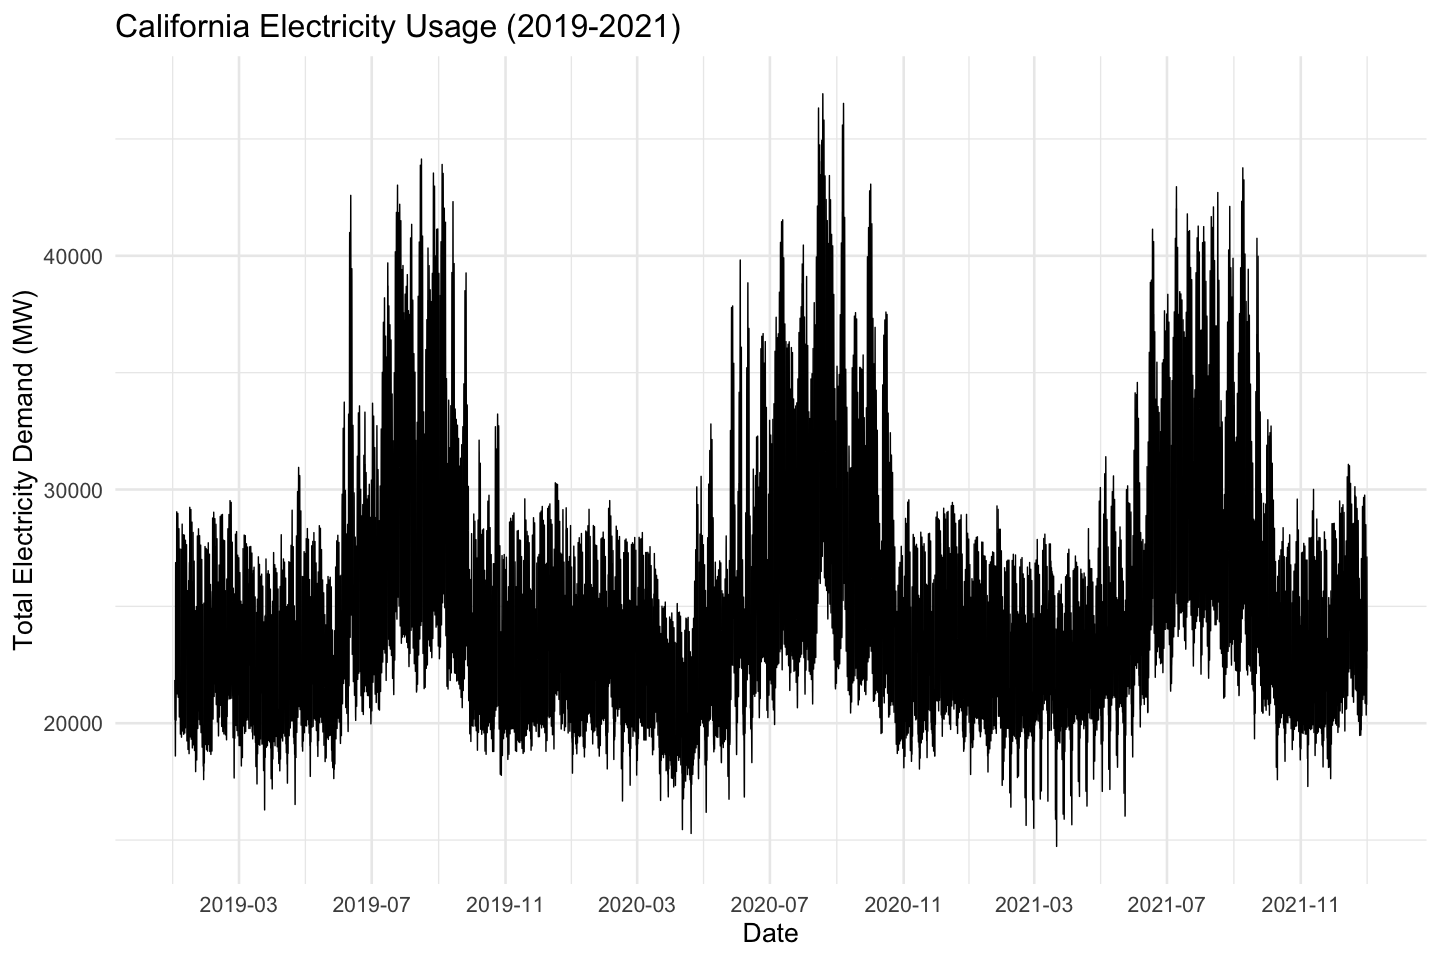

In [212]:
autoplot(dat_ts, Electric_demand, linewidth=0.4) +
    ggtitle("California Electricity Usage (2019-2021)") +
    ylab("Total Electricity Demand (MW)") +
    xlab("Date") +
    scale_x_datetime(
        date_breaks = "4 months",
        date_labels = "%Y-%m")

Three years of hourly demand. The outer envelope of the dense plot indicates the seasonal maxima and minima. Demand ranges from winter minima near 15,000 MW to summer maxima near 47,000 MW.

There is clear annual seasonality but no obvious trend across the three years, which I check next with STL decomposition. This suggests that seasonal differencing will be the appropriate approach for SARIMA later, and that calendar variables should be useful predictors.

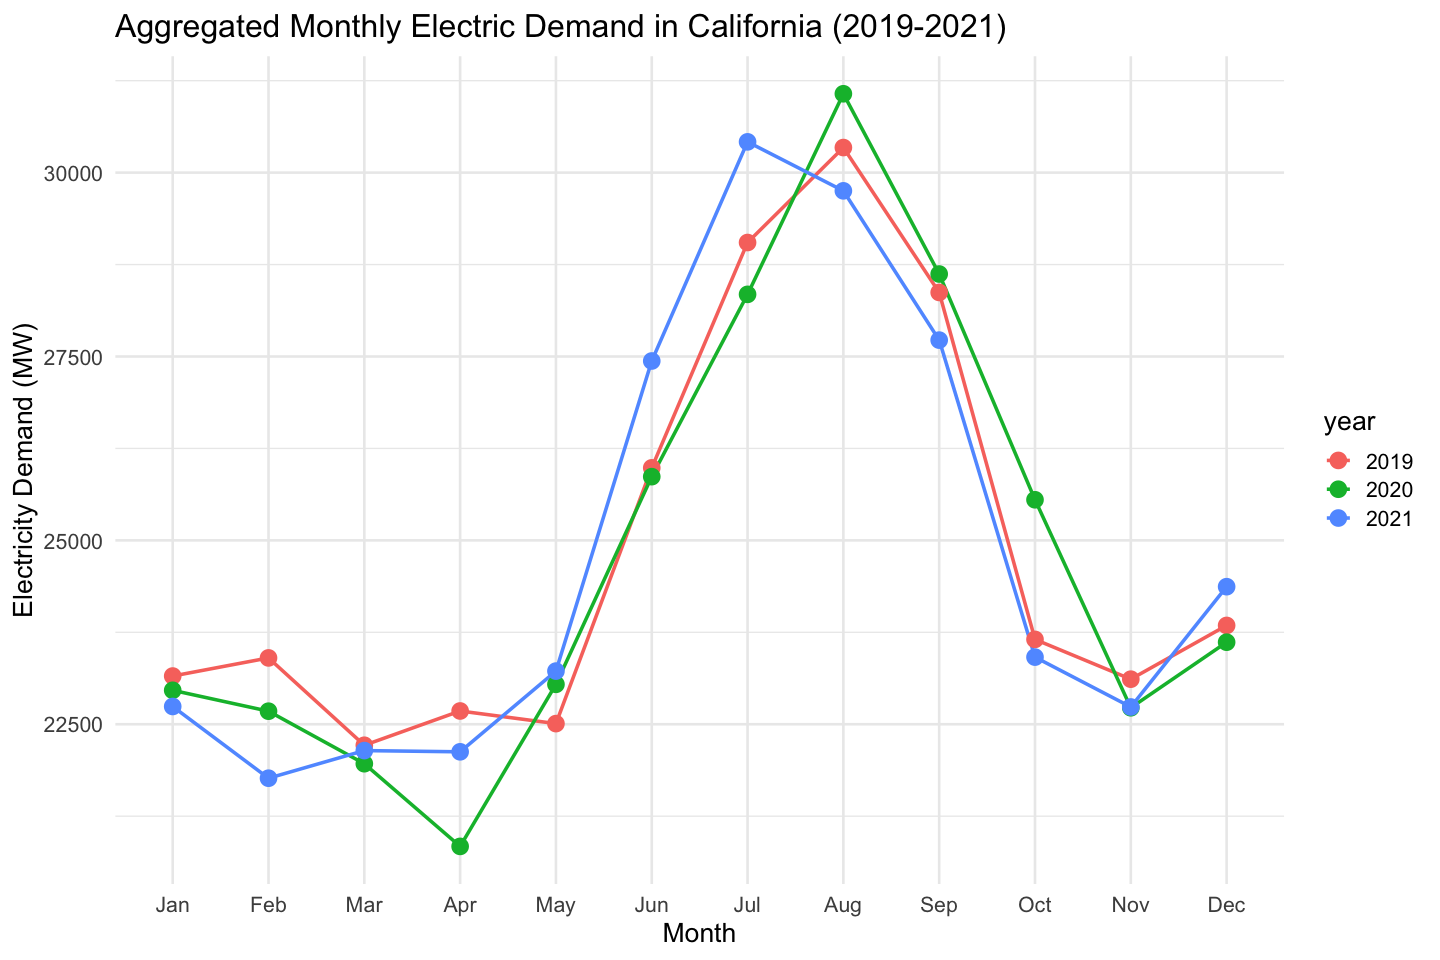

In [213]:
monthly_avg <- dat_ts %>%
  as_tibble() %>%  # Convert tsibble to tibble for aggregation
  mutate(month = month(Time, label = TRUE),
        year = as.character(year(Time))) %>%
  group_by(month, year) %>%
  summarize(avg_demand = mean(Electric_demand, na.rm = TRUE), .groups = 'drop')

ggplot(monthly_avg, aes(x = month, y = avg_demand, color = year, group = year)) +
  geom_line(linewidth = 1) +
  geom_point(size = 4) +
  labs(y = "Electricity Demand (MW)",
       x = "Month",
       title = "Aggregated Monthly Electric Demand in California (2019-2021)")

Averaging by month and year separates the annual cycle from year-to-year differences.

Summer peaks dominate in all three years, but 2020 runs above 2019 and 2021 from roughly August through October. COVID-19 is a plausible explanation, since more people were at home during the day. April 2020 shows distinctly low demand, which is consistent with stay-at-home orders closing businesses. This is a structural difference inside the training data that the model treats as ordinary variation.

season_name,max_rise
<chr>,<dbl>
Autumn,1631
Spring,1190
Summer,1697
Winter,1924


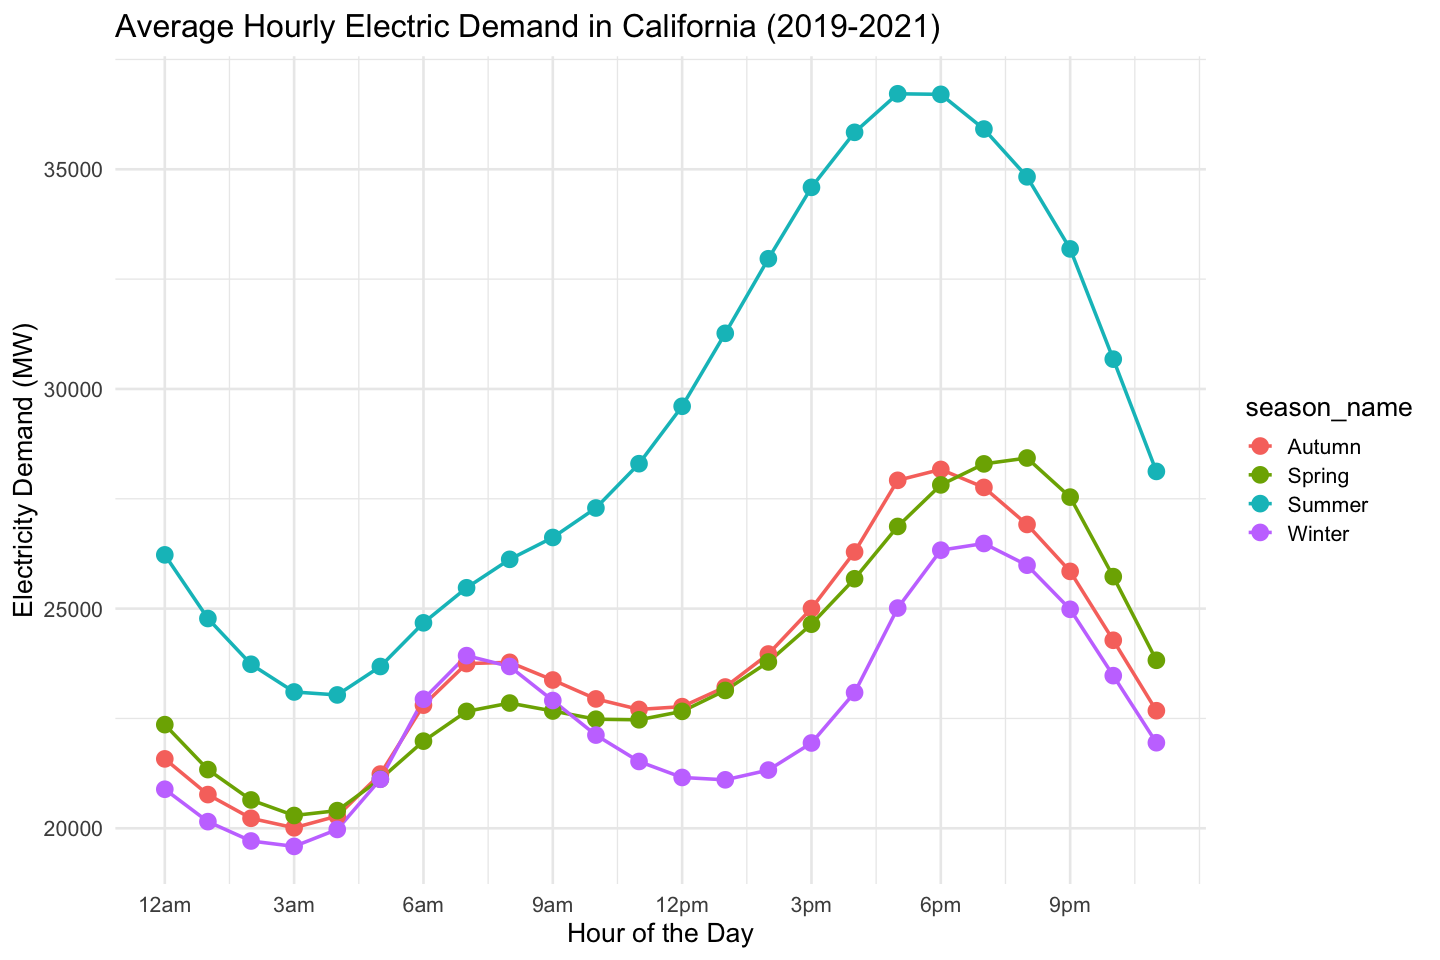

In [214]:
hourly_avg <- dat_ts %>%
  as_tibble() %>%  # Convert tsibble to tibble for aggregation
  mutate(hour = hour(Time),
         season_name = case_when(
              Season == 1 ~ "Winter",
              Season == 2 ~ "Spring",
              Season == 3 ~ "Summer",
              Season == 4 ~ "Autumn"
    )) %>%
  group_by(hour, season_name) %>%
  summarize(avg_demand = mean(Electric_demand, na.rm = TRUE), .groups = 'drop')

# Calculate the maximum rise in demand for each season
hourly_avg %>% 
  group_by(season_name) %>% 
  summarize(max_rise = round(max(diff(avg_demand)), 0))
  
ggplot(hourly_avg, aes(x = hour, y = avg_demand, color = season_name)) +
  geom_line(linewidth = 1) +
  geom_point(size = 4) +
  scale_x_continuous(breaks = seq(0, 23, 3),
                     labels = c("12am", "3am", "6am", "9am", "12pm", "3pm", "6pm", "9pm")) +
  labs(y = "Electricity Demand (MW)",
       x = "Hour of the Day",
       title = "Average Hourly Electric Demand in California (2019-2021)")

The daily shape is broadly similar across seasons: a trough around 4am, a small morning rise, and a larger evening peak. Summer shifts the peak earlier and 8,000-10,000 MW higher.

Two features matter for specification. The evening rise is steeper than the morning rise in every season, and a shape with that much asymmetry will not be captured well by a smooth sine term, so I use 24 separate hour-of-day indicators instead. The spring and autumn curves are also noticeably flat through the middle of the day despite those being the sunniest hours, which is the rooftop solar offset.

<a id="sec12"></a>
### 1.2 Distributions

Checking the marginal distributions to see whether anything needs transforming before it goes into a linear model.

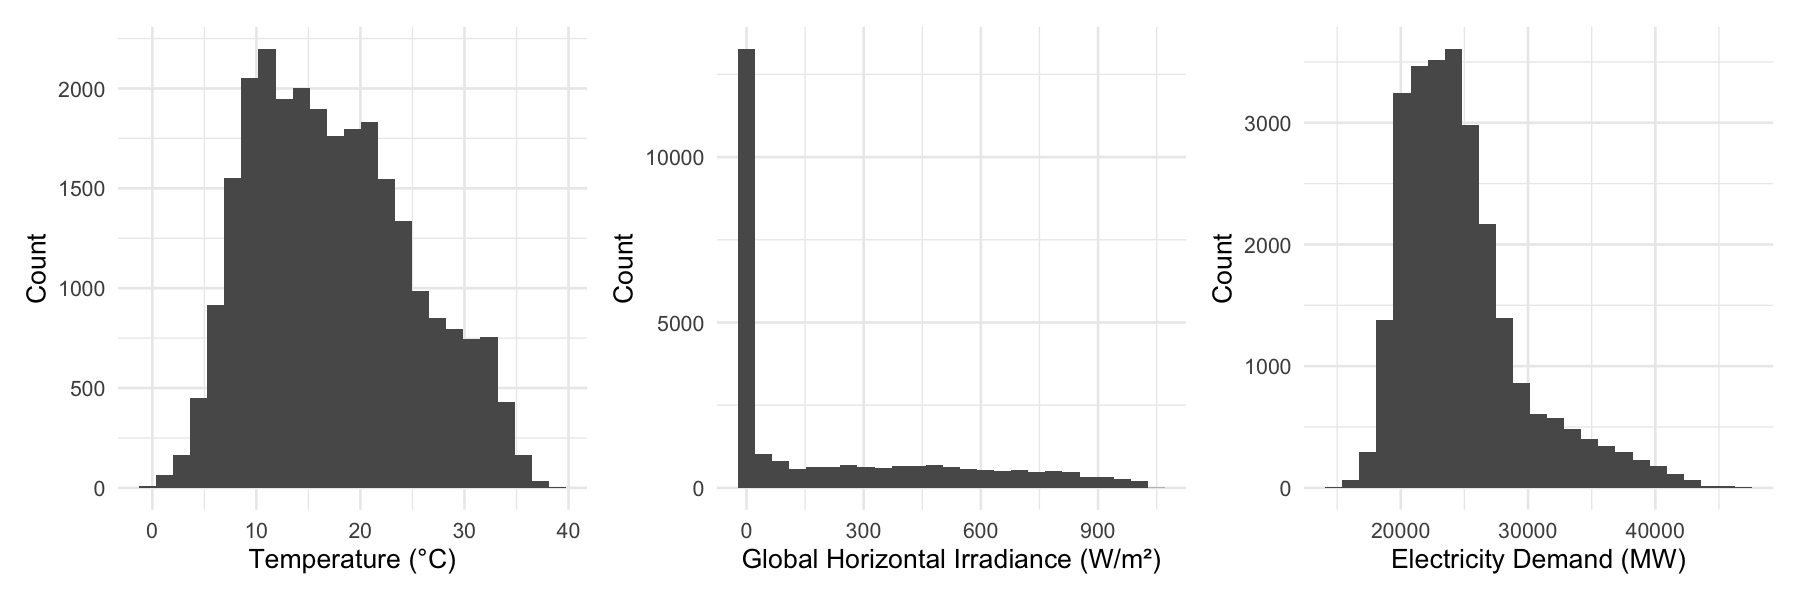

In [215]:
p1 <- ggplot(dat_ts, aes(x = Temperature)) +
  geom_histogram(bins = 25) +
  labs(x = "Temperature (°C)",
       y = "Count")

p2 <- ggplot(dat_ts, aes(x = GHI)) +
  geom_histogram(bins = 25) +
  labs(x = "Global Horizontal Irradiance (W/m²)",
       y = "Count")

p3 <- ggplot(dat_ts, aes(x = Electric_demand)) +
  geom_histogram(bins = 25) +
  labs(x = "Electricity Demand (MW)",
       y = "Count")

options(repr.plot.width = 15, repr.plot.height = 5)
(p1 | p2 | p3)

Temperature is roughly symmetric. Demand is right-skewed with a long upper tail from summer afternoons. Irradiance is heavily right-skewed with a large spike at zero, which is simply night: about half the hours have no sun.

The zeros are night, not missing data, so I leave the variable untransformed. Demand's skew is mild enough for OLS, but it suggests errors will be largest at high demand.

<a id="sec13"></a>
### 1.3 Decomposition and autocorrelation

STL decomposition splits the series into trend and seasonal components.

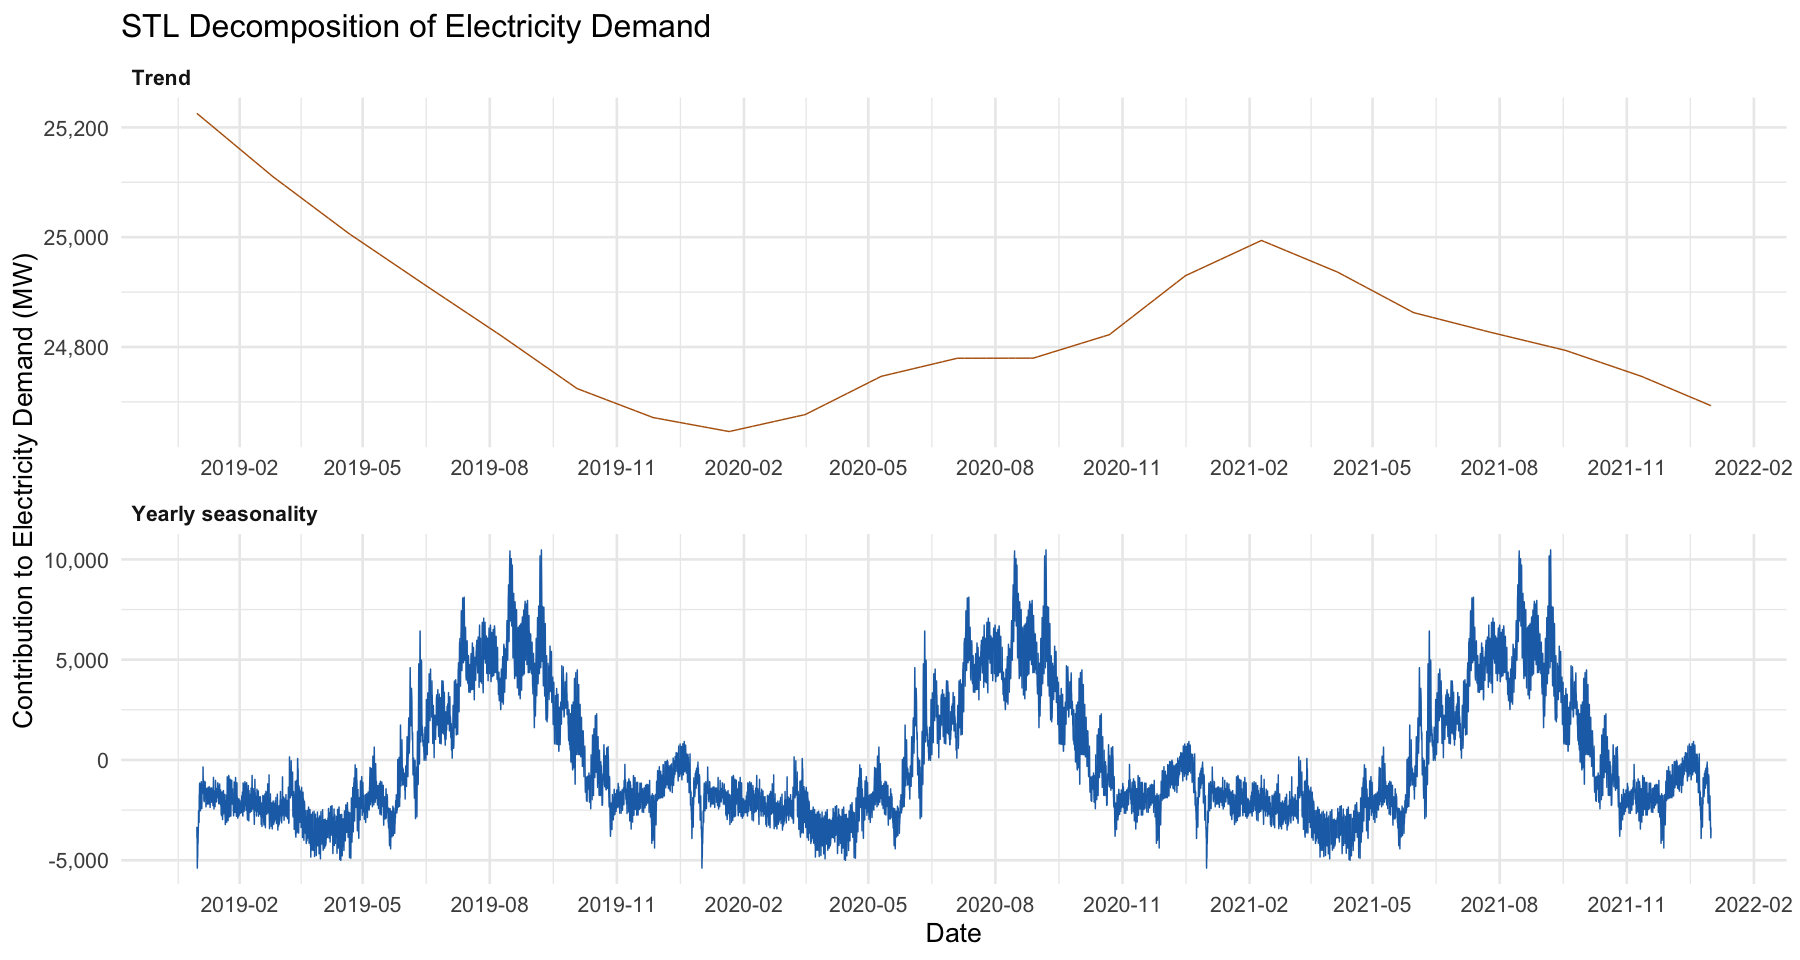

In [216]:
# STL decomposition into trend and seasonal components (all in MW)
decomp_simple <- dat_ts %>%
  model(STL(Electric_demand ~ season(window = 365))) %>%
  components()

# Plot the trend and the yearly seasonal component
options(repr.plot.width = 15, repr.plot.height = 8)
decomp_simple %>%
  as_tibble() %>%
  select(Time, trend, season_year) %>%
  pivot_longer(c(trend, season_year), names_to = "component", values_to = "value") %>%
  mutate(component = factor(component,
                            levels = c("trend", "season_year"),
                            labels = c("Trend", "Yearly seasonality"))) %>%
  ggplot(aes(x = Time, y = value, color = component)) +
  geom_line(linewidth = 0.4) +
  facet_wrap(~component, scales = "free_y", ncol = 1, axes = "all_x") +
  scale_x_datetime(date_breaks = "3 months", date_labels = "%Y-%m") +
  scale_y_continuous(labels = scales::comma) +
  scale_color_manual(values = c("Trend" = "#B45F06", "Yearly seasonality" = "#1F6FB4")) +
  labs(title = "STL Decomposition of Electricity Demand",
       x = "Date",
       y = "Contribution to Electricity Demand (MW)") +
  theme(legend.position = "none",
        strip.text = element_text(face = "bold", hjust = 0))

The trend component moves within a 580 MW band over three years, against a yearly seasonal swing of about 15,900 MW. The trend is close to flat by comparison, so most of the systematic variation is seasonal.

This is consistent with the raw series, and it implies that if the model captures the seasonality, the residuals should be close to stationary, which is what the SARIMA stage requires.

ACF and PACF plots show how much the series depends on its own past values.

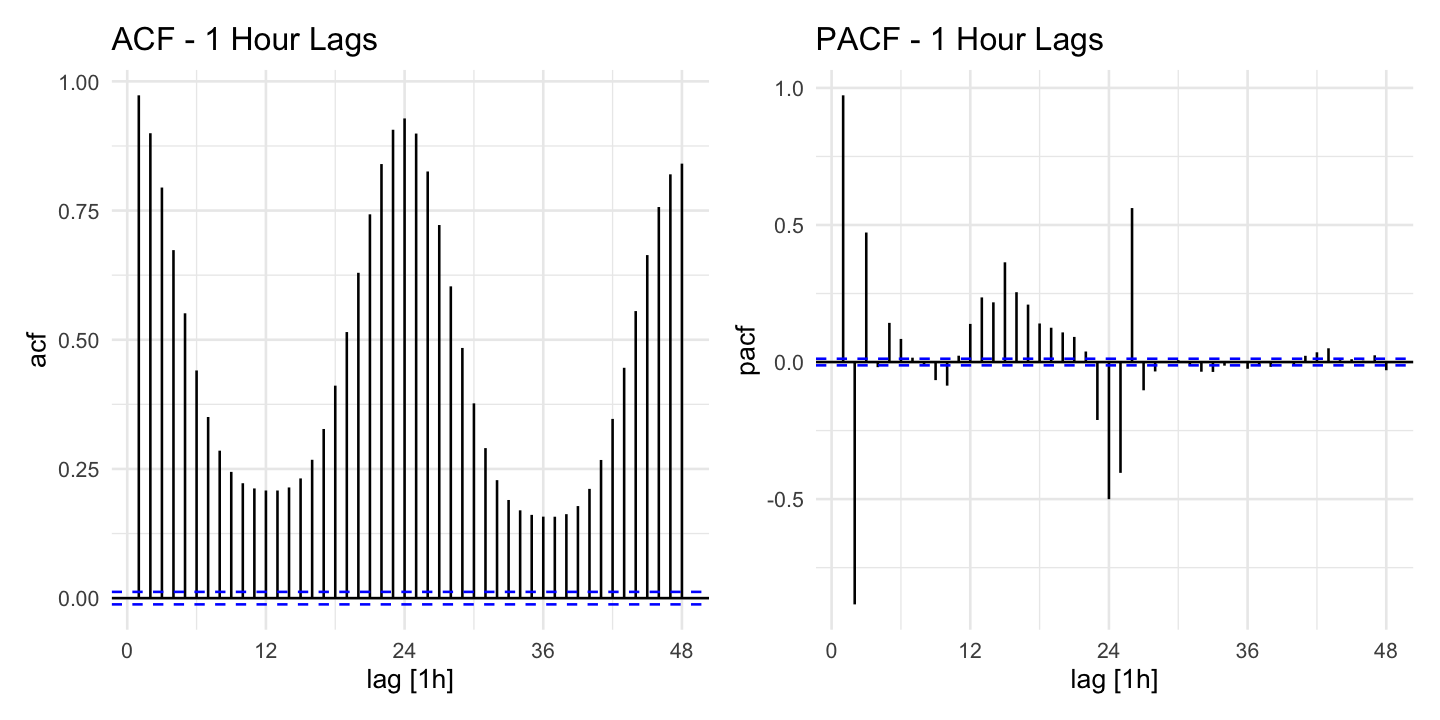

In [217]:
# ACF and PACF plots to check for autocorrelation
p1 <- dat_ts %>%
  ACF(Electric_demand, lag_max = 48) %>%  # 48 hourly lags
  autoplot() +
  ggtitle("ACF - 1 Hour Lags")

p2 <- dat_ts %>%
  PACF(Electric_demand, lag_max = 48) %>%
  autoplot() +
  ggtitle("PACF - 1 Hour Lags")

options(repr.plot.width = 12, repr.plot.height = 6)
(p1 | p2)

The ACF decays slowly with a clear 24-lag period, reflecting the daily seasonality in demand. The lag-1 autocorrelation is very large, which is worth noting early: any model given the previous hour's demand will score well, and whether that score reflects genuine forecasting skill depends entirely on whether the previous hour's demand is actually available at the time the forecast is made.

The PACF reflects the individual contribution of each lag. Each group of lags corrects the previous group's overshoot, with lags 1 to 3 describing the shape of the local curve and lags around 24 describing the daily cycle, which is why the signs alternate and why the corrections die out once the daily structure is accounted for.

Together these point to a low-order AR term plus a seasonal component at period 24, which is the specification used in Section 4.

<a id="sec14"></a>
### 1.4 Demand and its drivers

In [218]:
# Correlation matrix for key predictors
cor_vars <- dat_ts %>%
  select(Electric_demand, Temperature, GHI, Season, Day_of_the_week) %>%
  as_tibble() %>%
  select(-Time) %>%
  cor(use = "complete.obs")

# Display correlation matrix
cor_vars %>%
  knitr::kable(digits = 3, caption = "Correlation Matrix of Key Variables")



Table: Correlation Matrix of Key Variables

|                | Electric_demand| Temperature|    GHI| Season| Day_of_the_week|
|:---------------|---------------:|-----------:|------:|------:|---------------:|
|Electric_demand |           1.000|       0.552|  0.045|  0.205|          -0.169|
|Temperature     |           0.552|       1.000|  0.625|  0.254|           0.008|
|GHI             |           0.045|       0.625|  1.000| -0.025|           0.004|
|Season          |           0.205|       0.254| -0.025|  1.000|          -0.003|
|Day_of_the_week |          -0.169|       0.008|  0.004| -0.003|           1.000|

Temperature is the strongest single correlate of demand (r = 0.55). Irradiance correlates strongly with temperature (r = 0.63), since sunny hours are warm hours, but its raw correlation with demand is almost exactly zero (r = 0.045).

That near-zero value hides two effects working in opposite directions: sunny hours are hot hours, which raises cooling demand, and sunny hours also have more rooftop generation, which reduces the demand the grid measures. The raw correlation cannot separate them; holding temperature fixed can, which the next figure does.

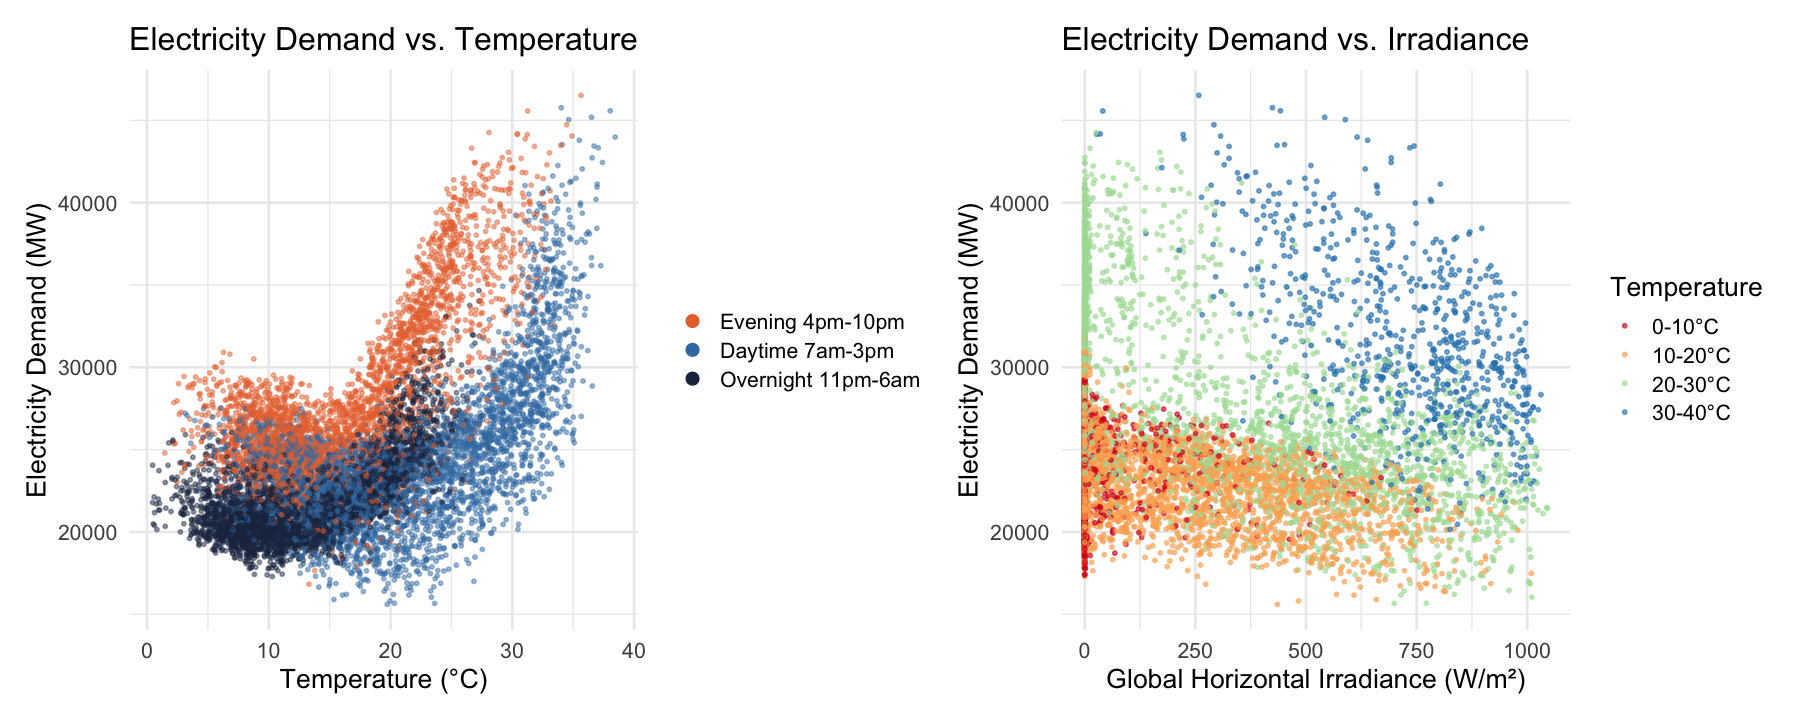

In [219]:
# Set seed for reproducibility
set.seed(123)

# Determine sample size
sample_size <- 10000
dat_sample <- dat_ts[sample(nrow(dat_ts), sample_size), ]

# Create time of day levels for demand vs temp scatter
dat_sample <- dat_sample %>%
  mutate(hour_block = factor(case_when(
    hour(Time) >= 16 & hour(Time) <= 22 ~ "Evening 4pm-10pm",
    hour(Time) >= 7  & hour(Time) <= 15 ~ "Daytime 7am-3pm",
    TRUE                                ~ "Overnight 11pm-6am"),
    levels = c("Evening 4pm-10pm", "Daytime 7am-3pm", "Overnight 11pm-6am")))

# Demand vs. temperature
p1 <- ggplot(dat_sample, aes(x = Temperature, y = Electric_demand, color = hour_block)) +
  geom_point(alpha = 0.45, size = 0.7) +
  scale_color_manual(values = c("#E8743B", "#3E7CB1", "#20304F")) +
  guides(color = guide_legend(override.aes = list(size = 3, alpha = 1))) +
  labs(x = "Temperature (°C)", y = "Electricity Demand (MW)",
       title = "Electricity Demand vs. Temperature", color = NULL)

# Electricity demand vs. irradiance, colored by temperature band
p2 <- dat_sample %>%
  mutate(temp_bin = cut(Temperature,
                        breaks = c(-Inf, 0, 10, 20, 30, 40, Inf),
                        labels = c("<0°C", "0-10°C", "10-20°C", "20-30°C", "30-40°C", ">40°C"))) %>%
  ggplot(aes(x = GHI, y = Electric_demand, color = temp_bin)) +
  geom_point(alpha = 0.6, size = 0.7) +
  labs(x = "Global Horizontal Irradiance (W/m²)",
       y = "Electricity Demand (MW)",
       title = "Electricity Demand vs. Irradiance",
       color = "Temperature") +
  scale_color_brewer(palette = "Spectral")

options(repr.plot.width = 15, repr.plot.height = 6)
(p1 | p2)

The temperature relationship is U-shaped, which motivates including a squared temperature term in the regression. Time of day also shifts the position of the curve, since evening usage is highest and overnight usage lowest, and temperature shifts time of day.

The irradiance panel shows the confound with temperature directly. In every temperature band above 10°C the relationship slopes downward, and more steeply the hotter the band. The bands themselves are stacked so that the hotter and sunnier ones sit higher, which is why the pooled association is flat.

That downward within-band slope is rooftop solar at work. Power generated on a roof and used in the building below never passes through a grid meter, so it appears in the CAISO series as demand that is not there. I treat irradiance as a control variable rather than a causal estimate, since it stays correlated with temperature and its coefficient will absorb some of both.

<a id="sec2"></a>
## 2. Data preparation and baselines

[Back to contents](#toc)

In this section I prepare the data for modeling, set out the two horizons the forecast has to cover, and fit the naive baselines that later results are compared against. 

<a id="sec21"></a>
### 2.1 Feature construction and the train/test split

In [220]:
# Create time series features for regression
dat_ts_reg <- dat_ts %>%
  mutate(
    # Time-based features
    hour_of_day = hour(Time),
    # Lagged demand (1 hour back)
    lag1_demand = lag(Electric_demand, 1),
    # Convert categorical variables to factors
    Season = as.factor(Season),
    Day_of_the_week = as.factor(Day_of_the_week),
    hour_of_day = as.factor(hour_of_day)
  ) %>%
  drop_na() # Remove rows with NA from lagging

In [221]:
# Split data into training and test sets for forecasting evaluation
test_intervals <- 168
dat_train <- dat_ts_reg[1:(nrow(dat_ts_reg) - test_intervals), ]
dat_val <- dat_ts_reg[(nrow(dat_ts_reg) - test_intervals + 1):nrow(dat_ts_reg), ]

cat("Training set:", nrow(dat_train), "observations\n")
cat("Test set:", nrow(dat_val), "observations\n")

print(range(dat_train$Time))
print(range(dat_val$Time))

Training set: 26135 observations
Test set: 168 observations
[1] "2019-01-01 01:00:00 UTC" "2021-12-24 23:00:00 UTC"
[1] "2021-12-25 00:00:00 UTC" "2021-12-31 23:00:00 UTC"


I hold out the last seven days, 168 hourly observations, as a test set. The split is chronological, since the task is forecasting. 

The test window runs from 25 to 31 December 2021, which is a holiday week and therefore unlikely to be representative. Section 5 repeats the exercise over twelve consecutive windows for that reason.

<a id="sec22"></a>
### 2.2 Two forecast horizons

A forecast is only meaningful relative to the information available when it is made, so I carry out two horizons:

**One hour ahead (h = 1).** The forecaster knows demand up to the previous hour. The lagged demand term `lag1_demand` is therefore a legitimate predictor, since its value has already been observed.

**One week ahead (h = 168).** The forecaster knows demand only up to the start of the week. By the third hour of the forecast, the previous hour's demand is itself a prediction. A specification containing `lag1_demand` can only be used at this horizon by feeding its own output back in recursively, which accumulates error. The alternative is to drop the term, which gives a specification valid at any horizon.

I therefore fit two regressions, one per horizon, and evaluate each against a baseline appropriate to its own information set. Both use observed weather for the test period, which is an optimistic assumption at the week-ahead horizon.

<a id="sec23"></a>
### 2.3 Naive baselines

I set a naive baseline at each horizon to establish what accuracy is achievable with virtually no information. That lets me read the model's error as an improvement over doing nothing.

- Persistence predicts that demand equals its most recent observed value: h = 1. 
- Seasonal naive predicts the same hour one week earlier: h = 168.

In [222]:
# Error metrics used throughout
metrics <- function(actual, fc) {
  c(
    MAE  = mean(abs(actual - fc)),
    RMSE = sqrt(mean((actual - fc)^2)),
    MAPE = mean(abs((actual - fc) / actual)) * 100
    )
}

actual <- dat_val$Electric_demand
full_demand <- dat_ts_reg$Electric_demand
n_full <- nrow(dat_ts_reg)
H <- test_intervals

# Persistence: yhat[t] = y[t-1]
naive_persist <- dat_val$lag1_demand
# Seasonal naive: yhat[t] = y[t-168]
snaive_168 <- full_demand[(n_full - H + 1 - 168):(n_full - 168)]

baseline_table <- rbind(
  "Persistence  y[t-1]        (h = 1)"   = metrics(actual, naive_persist),
  "Seasonal naive  y[t-168]   (h = 168)" = metrics(actual, snaive_168)
)

kable(baseline_table, digits = 2,
      caption = "Baseline Accuracy on the Held-Out Week")

cat("\nMean demand over the test week:", round(mean(actual)), "MW\n")



Table: Baseline Accuracy on the Held-Out Week

|                                     |     MAE|    RMSE| MAPE|
|:------------------------------------|-------:|-------:|----:|
|Persistence  y[t-1]        (h = 1)   |  733.52|  919.03| 3.05|
|Seasonal naive  y[t-168]   (h = 168) | 1197.15| 1581.49| 5.27|


Mean demand over the test week: 23759 MW


These are the numbers the models have to beat. At one hour ahead, persistence achieves 3.05% MAPE, which is a demanding target: demand simply does not change very much in an hour. At one week ahead, repeating the previous week achieves 5.27%.

The gap between the two is larger than it might appear. A model reporting 1.5% MAPE at h = 1 has halved the error, while the same figure at h = 168 would be a much larger achievement.

<a id="sec3"></a>
## 3. OLS regression

[Back to contents](#toc)

I start with OLS because the coefficients are directly interpretable, which addresses the first research question. The exploratory analysis determines the specification:

$$\text{Demand}_t = \beta_0 + \beta_1 T_t + \beta_2 T_t^2 + \beta_3 \text{GHI}_t + \sum_s \gamma_s \text{Season}_{s,t} + \sum_d \delta_d \text{DoW}_{d,t} + \sum_h \eta_h \text{Hour}_{h,t} + \phi\, \text{Demand}_{t-1} + \varepsilon_t$$

The squared temperature term comes from the U-shape in 1.4, the 24 hour indicators from the asymmetric daily curve in 1.1, and irradiance from the rooftop solar argument in Section 0. The season, day-of-week and hour terms are sets of indicator variables, so each sum contributes the coefficient for whichever category hour $t$ falls into.

The h = 1 specification estimates this equation in full. The h = 168 specification imposes $\phi = 0$, since the previous hour's demand is not available at that horizon.

<a id="sec31"></a>
### 3.1 Fitting the two specifications

In [223]:
# h = 1 specification: includes the observed previous hour
model_lag <- lm(Electric_demand ~ Temperature + I(Temperature^2) + GHI +
                Season + Day_of_the_week + hour_of_day + lag1_demand,
                data = dat_train)

# h = 168 specification: no lagged demand, valid at any horizon
model_nolag <- lm(Electric_demand ~ Temperature + I(Temperature^2) + GHI +
                  Season + Day_of_the_week + hour_of_day,
                  data = dat_train)

summary(model_nolag)


Call:
lm(formula = Electric_demand ~ Temperature + I(Temperature^2) + 
    GHI + Season + Day_of_the_week + hour_of_day, data = dat_train)

Residuals:
    Min      1Q  Median      3Q     Max 
-8712.6 -1163.1   -97.3  1137.5  8734.7 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)      24384.1063    89.6850 271.886  < 2e-16 ***
Temperature       -576.2703     8.2041 -70.241  < 2e-16 ***
I(Temperature^2)    27.6627     0.2137 129.420  < 2e-16 ***
GHI                -13.6110     0.1398 -97.354  < 2e-16 ***
Season2            354.5564    45.1695   7.849 4.34e-15 ***
Season3           1908.9710    57.3115  33.309  < 2e-16 ***
Season4           -138.0714    36.9958  -3.732 0.000190 ***
Day_of_the_week1   404.2864    44.4351   9.098  < 2e-16 ***
Day_of_the_week2   461.7882    44.4317  10.393  < 2e-16 ***
Day_of_the_week3   463.0168    44.4356  10.420  < 2e-16 ***
Day_of_the_week4   153.3315    44.4428   3.450 0.000561 ***
Day_of_the_week5 -1539.1160    

The standard errors and significance stars assume independent errors, which 3.3 shows is false here, so they are too small to trust. The coefficient estimates themselves are unaffected.

In [224]:
fit_table <- rbind(
  "With lag1_demand (h = 1)"  = c(R2 = summary(model_lag)$r.squared,
                                  adjR2 = summary(model_lag)$adj.r.squared,
                                  AIC = AIC(model_lag)),
  "Without lag1_demand (h = 168)" = c(R2 = summary(model_nolag)$r.squared,
                                  adjR2 = summary(model_nolag)$adj.r.squared,
                                  AIC = AIC(model_nolag))
)
kable(fit_table, digits = c(4, 4, 1), caption = "In-Sample Fit of the Two Specifications")



Table: In-Sample Fit of the Two Specifications

|                              |     R2|  adjR2|      AIC|
|:-----------------------------|------:|------:|--------:|
|With lag1_demand (h = 1)      | 0.9918| 0.9918| 392468.4|
|Without lag1_demand (h = 168) | 0.8441| 0.8439| 469350.0|

<a id="sec32"></a>
### 3.2 Reading the coefficients

The two specifications give very different in-sample fits: R² is 0.992 with the lagged term and 0.844 without it. Demand doesn't change much in an hour, so it makes sense that knowing the previous hour adds about fifteen percentage points. However, that term is unavailable beyond the first hour, and including it leaves the remaining coefficients describing deviations from the previous hour rather than demand itself. I therefore read the coefficients from the no-lag specification, which is also the better description of what the weather and calendar variables explain on their own.

- **Temperature** has a linear coefficient of −576 MW/°C and a squared coefficient of +27.7 MW/°C², which is the U-shape from 1.4 in numeric form. The fitted effect bottoms out near 10°C and is about 16,700 MW above that minimum by 35°C, making temperature the largest single contributor in the model.
- **Irradiance** has a coefficient of −13.6 MW per W/m², so 100 W/m² more sunlight is associated with roughly 1,360 MW less measured demand, holding temperature and hour of day fixed. The sign matches the rooftop solar mechanism.
- Relative to Monday, the omitted category, **Saturday** sits 1,539 MW lower and **Sunday** 2,317 MW lower, while the weekdays fall within a few hundred MW of each other, so the weekly pattern is essentially weekday against weekend. 
- **Summer** adds 1,909 MW relative to winter even after temperature is controlled for.
- **Hour-of-day** effects span 7,873 MW, from a minimum at 3am to a maximum at 7pm. That is after temperature and irradiance are controlled for, so it reflects usage patterns rather than weather. It is by far the largest calendar effect.

<a id="sec33"></a>
### 3.3 Diagnostics

OLS inference assumes residuals are normal, homoskedastic, and independent. I check each below, using the no-lag specification. The third assumption fails, as expected.

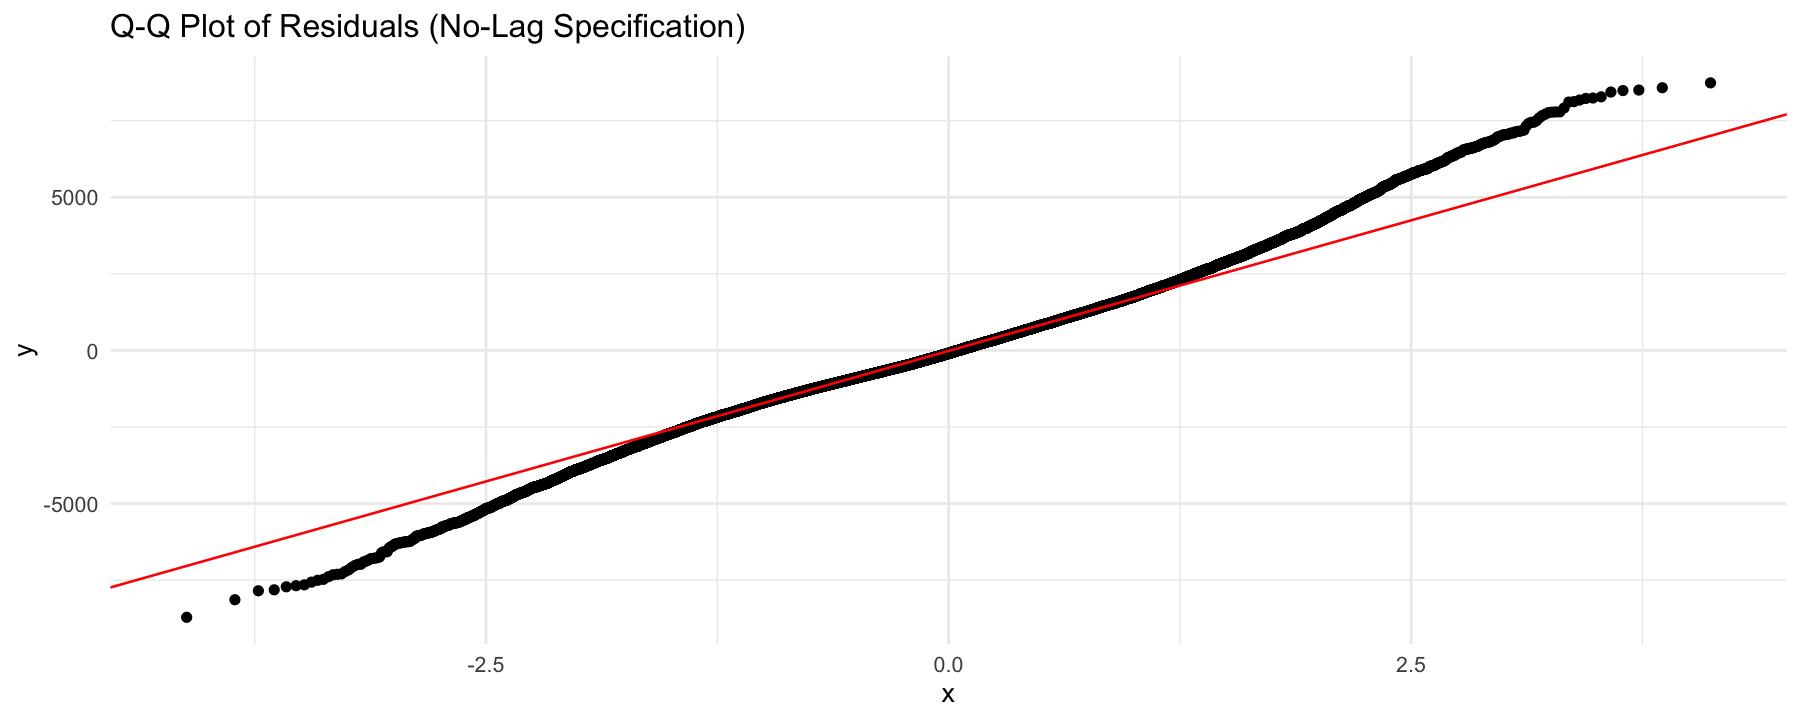

In [225]:
# Q-Q plot for normality
ggplot(data.frame(residuals = residuals(model_nolag)),
            aes(sample = residuals)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  labs(title = "Q-Q Plot of Residuals (No-Lag Specification)")

The Q-Q plot follows the normal line through the middle but deviates at both tails, so the confidence intervals are likely both too narrow and least reliable during extremes. The coefficients themselves remain unbiased.

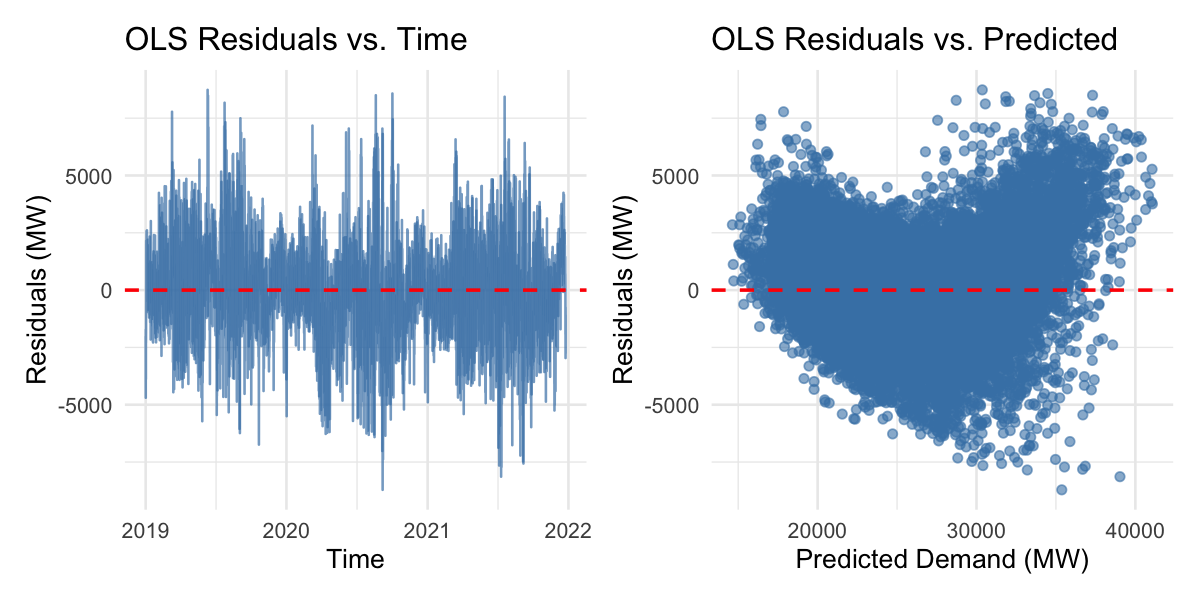

In [226]:
dat_train <- dat_train %>%
  mutate(nolag_train_pred = predict(model_nolag),
         nolag_resid = Electric_demand - nolag_train_pred)

# Residuals over time
p1 <- ggplot(dat_train, aes(x = Time, y = nolag_resid)) +
  geom_line(alpha = 0.7, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
  labs(y = "Residuals (MW)", x = "Time", title = "OLS Residuals vs. Time")

# Residuals vs predicted values
p2 <- ggplot(dat_train, aes(x = nolag_train_pred, y = nolag_resid)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
  labs(x = "Predicted Demand (MW)", y = "Residuals (MW)",
       title = "OLS Residuals vs. Predicted")

options(repr.plot.width = 10, repr.plot.height = 5)
(p1 | p2)

The residuals stay centered near zero over time while clustering in different stretches, and their spread is heteroskedastic: it widens as predicted demand increases.

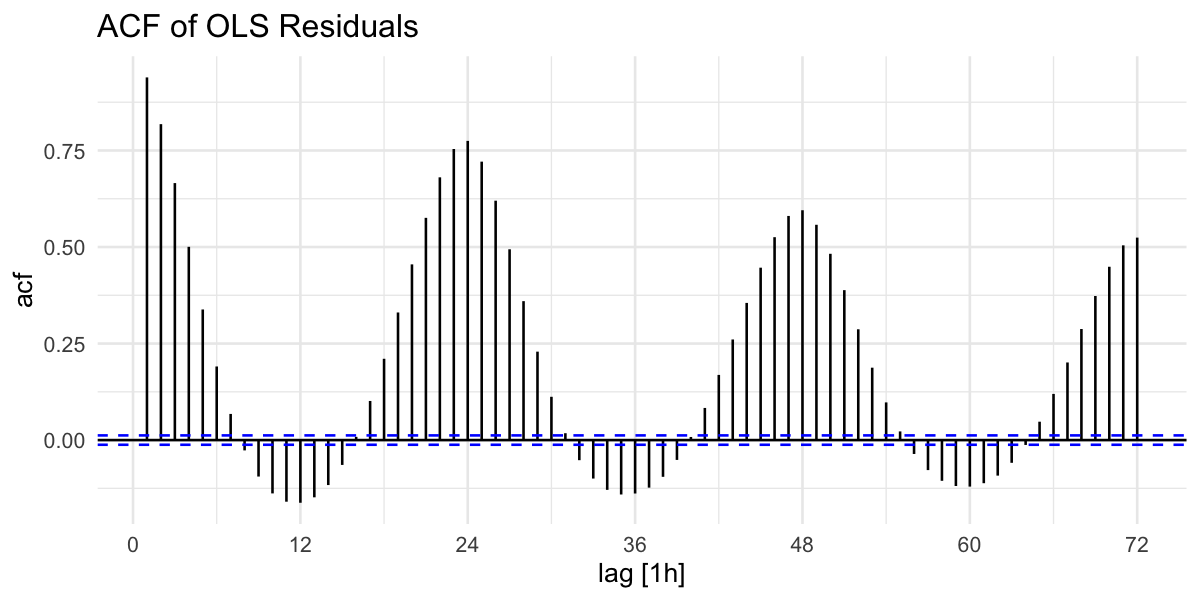

In [227]:
# Same ACF treatment as 1.3, applied to the no-lag residuals
dat_train %>%
  as_tibble() %>%
  select(Time, nolag_resid) %>%
  as_tsibble(index = Time) %>%
  ACF(nolag_resid, lag_max = 72) %>%
  autoplot() +
  ggtitle("ACF of OLS Residuals")

The residual ACF has strong autocorrelation at short lags and further structure at multiples of 24. Independence is the assumption that matters most for forecasting, and its failure means there is still predictable structure in the errors, which Section 4 sets out to capture.

<a id="sec34"></a>
### 3.4 Out-of-sample performance at both horizons

In [228]:
dat_val <- dat_val %>%
  mutate(pred_lag   = as.numeric(predict(model_lag,   newdata = dat_val)),
         pred_nolag = as.numeric(predict(model_nolag, newdata = dat_val)))

# Recursive use of the lagged specification over the full week, feeding predictions back in
recursive_fc <- numeric(H)
prev_demand  <- dat_train$Electric_demand[nrow(dat_train)]
for (i in seq_len(H)) {
  row_i <- dat_val[i, ]
  row_i$lag1_demand <- prev_demand              # own prediction, not observed value
  p <- as.numeric(predict(model_lag, newdata = row_i))
  recursive_fc[i] <- p
  prev_demand     <- p
}

ols_table <- rbind(
  "h = 1    Persistence (baseline)"      = metrics(actual, naive_persist),
  "h = 1    OLS + lag1"                  = metrics(actual, dat_val$pred_lag),
  "h = 168  Seasonal naive (baseline)"   = metrics(actual, snaive_168),
  "h = 168  OLS without lag"             = metrics(actual, dat_val$pred_nolag),
  "h = 168  OLS + lag1, fed recursively" = metrics(actual, recursive_fc)
)
kable(ols_table, digits = 2, caption = "OLS Against Its Baselines, Held-Out Week")



Table: OLS Against Its Baselines, Held-Out Week

|                                     |     MAE|    RMSE|  MAPE|
|:------------------------------------|-------:|-------:|-----:|
|h = 1    Persistence (baseline)      |  733.52|  919.03|  3.05|
|h = 1    OLS + lag1                  |  440.26|  515.21|  1.88|
|h = 168  Seasonal naive (baseline)   | 1197.15| 1581.49|  5.27|
|h = 168  OLS without lag             |  700.09|  907.65|  2.95|
|h = 168  OLS + lag1, fed recursively | 2839.62| 3027.16| 12.18|


- **At one hour ahead**, the regression achieves 1.88% MAPE against 3.05% for persistence, cutting the baseline's error by about 38%.

- **At one week ahead**, it achieves 2.95% against 5.27% for the seasonal naive baseline. That looks like a comparable improvement, but this particular week is Christmas, when repeating the previous week may be a more or less effective strategy. Section 5 tests whether the result survives on ordinary weeks, and it largely does not.

- Feeding the lagged specification's own predictions back in gives 12.18%, worse than doing nothing at all, because errors compound with no new observation to correct them, which is why lagged is dropped for one week ahead forecasts.

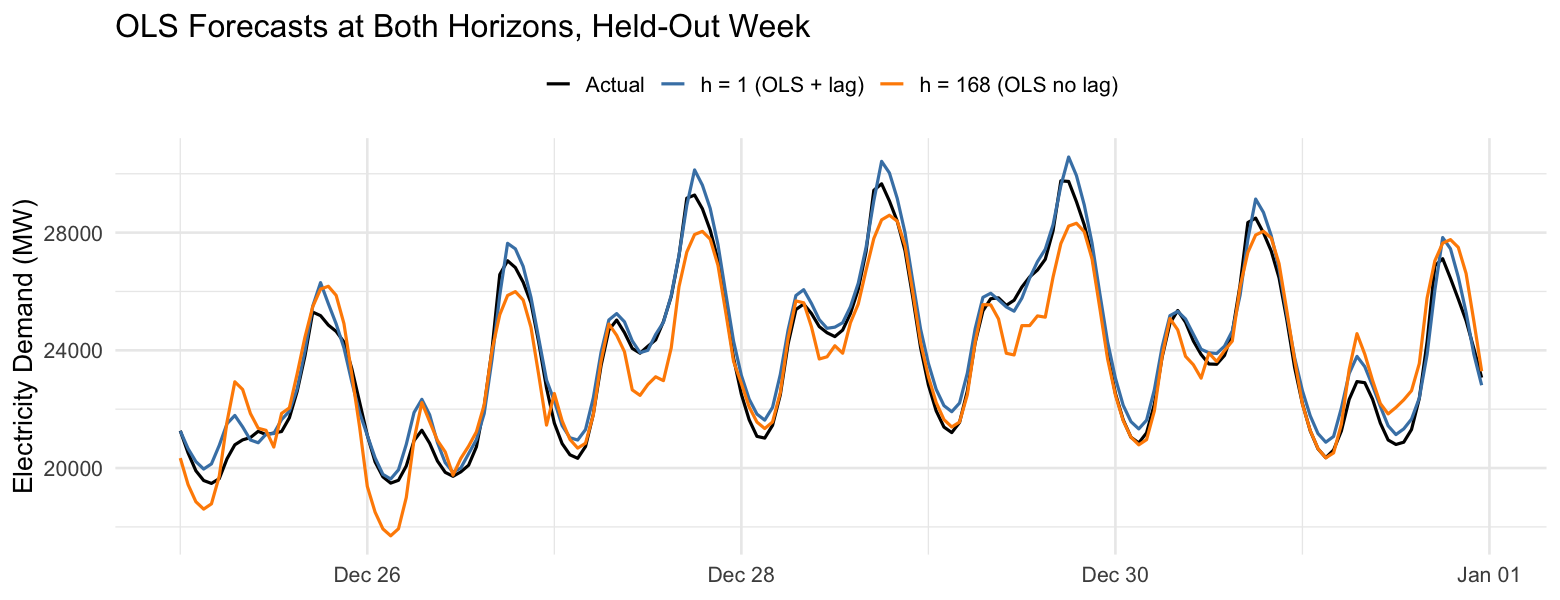

In [229]:
forecast_long <- dat_val %>%
  as_tibble() %>%
  select(Time, Actual = Electric_demand,
         `h = 1 (OLS + lag)` = pred_lag,
         `h = 168 (OLS no lag)` = pred_nolag) %>%
  pivot_longer(-Time, names_to = "series", values_to = "value")

options(repr.plot.width = 13, repr.plot.height = 5)
ggplot(forecast_long, aes(x = Time, y = value, color = series)) +
  geom_line(linewidth = 0.9) +
  scale_color_manual(values = c("Actual" = "black",
                                "h = 1 (OLS + lag)" = "steelblue",
                                "h = 168 (OLS no lag)" = "darkorange")) +
  labs(title = "OLS Forecasts at Both Horizons, Held-Out Week",
       y = "Electricity Demand (MW)", x = NULL, color = NULL) +
  theme(legend.position = "top")

- The one-hour-ahead forecast tracks the observed series throughout, but overshoots at the daily peaks and troughs (the residual temporal structure). 
- The week-ahead forecast largely reproduces the daily shape but underestimates the demand on most days, which is about the limit of what weather and calendar variables alone can do.

<a id="sec4"></a>
## 4. Hybrid model: OLS + SARIMA on the residuals

[Back to contents](#toc)

Since the OLS residuals are autocorrelated, the next step is to model them. OLS handles the weather and calendar effects, and a SARIMA model fits what is left over:

$$\hat{y}_t = \underbrace{\hat{y}_t^{\,\text{OLS}}}_{\text{weather + calendar}} + \underbrace{\hat{r}_t^{\,\text{SARIMA}}}_{\text{temporal structure}}$$

This keeps the OLS coefficients interpretable while capturing dynamics a static regression cannot represent. I fit one SARIMA model per horizon to the residuals of the corresponding regression.

<a id="sec41"></a>
### 4.1 Stationarity and model selection

SARIMA needs a stationary input. The Augmented Dickey-Fuller test has non-stationarity as its null hypothesis.

In [230]:
# Extract residuals from both OLS models and prepare as tsibbles
resid_lag <- dat_train %>%
  mutate(residuals = residuals(model_lag)) %>%
  select(Time, residuals) %>% as_tsibble(index = Time)

resid_nolag <- dat_train %>%
  mutate(residuals = residuals(model_nolag)) %>%
  select(Time, residuals) %>% as_tsibble(index = Time)

# Check stationarity of both residual series
resid_series <- list("h = 1 residuals"   = resid_lag$residuals,
                     "h = 168 residuals" = resid_nolag$residuals)

for (nm in names(resid_series)) {
  adf <- suppressWarnings(tseries::adf.test(resid_series[[nm]], alternative = "stationary"))
  cat(nm, ": ADF =", round(adf$statistic, 3), " p-value =", adf$p.value, "\n")
}

h = 1 residuals : ADF = -14.929  p-value = 0.01 
h = 168 residuals : ADF = -10.876  p-value = 0.01 


Both statistics are large and negative (p < 0.01), so the unit-root null is rejected in each case and both residual series are treated as stationary. 

In [231]:
LOAD_MODEL <- TRUE

fit_or_load <- function(res_data, path) {
  if (LOAD_MODEL && file.exists(path)) {
    cat("Loaded saved model:", path, "\n")
    readRDS(path)
  } else {
    cat("Fitting SARIMA via stepwise search (about a minute):", path, "\n")
    m <- res_data %>% model(sarima = ARIMA(residuals ~ PDQ(period = 24)))
    saveRDS(m, path)
    m
  }
}

# Season period = 24 for daily patterns in hourly data
sarima_lag   <- fit_or_load(resid_lag,   "outputs/sarima_h1.rds")
sarima_nolag <- fit_or_load(resid_nolag, "outputs/sarima_h168.rds")

Loaded saved model: outputs/sarima_h1.rds 
Loaded saved model: outputs/sarima_h168.rds 


In [232]:
cat("=== SARIMA on h = 1 residuals ===\n");   report(sarima_lag)
cat("\n=== SARIMA on h = 168 residuals ===\n"); report(sarima_nolag)

=== SARIMA on h = 1 residuals ===
Series: residuals 
Model: ARIMA(4,0,1)(0,1,1)[24] 

Coefficients:
         ar1      ar2     ar3      ar4      ma1     sma1
      1.6824  -0.9242  0.1787  -0.0235  -0.7401  -0.7220
s.e.  0.0264   0.0268  0.0128   0.0065   0.0257   0.0058

sigma^2 estimated as 44851:  log likelihood=-176894.9
AIC=353803.8   AICc=353803.8   BIC=353861

=== SARIMA on h = 168 residuals ===
Series: residuals 
Model: ARIMA(2,0,2)(2,1,0)[24] 

Coefficients:
         ar1      ar2      ma1      ma2     sar1     sar2
      1.6215  -0.7020  -0.4571  -0.0151  -0.4024  -0.3200
s.e.  0.0115   0.0099   0.0129   0.0082   0.0060   0.0059

sigma^2 estimated as 238684:  log likelihood=-198716.6
AIC=397447.2   AICc=397447.2   BIC=397504.4


The stepwise AICc search selects ARIMA(4,0,1)(0,1,1)[24] for the h = 1 residuals and ARIMA(2,0,2)(2,1,0)[24] for the h = 168 residuals. Both take one seasonal difference at lag 24 and no non-seasonal difference, which is consistent with the ADF result and with the lag-24 structure in the PACF. The search settles on a different seasonal structure for each horizon: one seasonal MA term for h = 1, and two seasonal AR terms for h = 168.

<a id="sec42"></a>
### 4.2 Diagnostics

In [233]:
hybrid_train <- dat_train %>%
  mutate(sarima_fitted = augment(sarima_nolag)$.fitted,
         hybrid_pred   = nolag_train_pred + sarima_fitted,
         hybrid_resid  = Electric_demand - hybrid_pred)

# In-sample R2, no-lag OLS alone vs. hybrid
sse <- function(e) sum(e^2, na.rm = TRUE)
sst <- sum((hybrid_train$Electric_demand - mean(hybrid_train$Electric_demand))^2)
cat("In-sample R-squared, OLS alone :", round(1 - sse(hybrid_train$nolag_resid) / sst, 4), "\n")
cat("In-sample R-squared, hybrid    :", round(1 - sse(hybrid_train$hybrid_resid) / sst, 4), "\n\n")

# Ljung-Box: check for residual autocorrelation.
# fitdf discounts estimated ARMA parameters: none for the raw OLS residuals, six for the SARIMA
lb_ols <- Box.test(hybrid_train$nolag_resid,  lag = 48, type = "Ljung-Box")
lb_hyb <- Box.test(hybrid_train$hybrid_resid, lag = 48, type = "Ljung-Box", fitdf = 6)
cat("Ljung-Box (lags 1-48)\n")
cat("  OLS alone : X-squared =", round(lb_ols$statistic, 1),
    " p-value =", format.pval(lb_ols$p.value, digits = 3), "\n")
cat("  Hybrid    : X-squared =", round(lb_hyb$statistic, 1),
    " p-value =", format.pval(lb_hyb$p.value, digits = 3), "\n")
cat("  Reduction in test statistic:",
    round((1 - lb_hyb$statistic / lb_ols$statistic) * 100, 1), "%\n")

In-sample R-squared, OLS alone : 0.8441 
In-sample R-squared, hybrid    : 0.9899 

Ljung-Box (lags 1-48)
  OLS alone : X-squared = 201128.3  p-value = <2e-16 
  Hybrid    : X-squared = 1581.1  p-value = <2e-16 
  Reduction in test statistic: 99.2 %


The SARIMA stage improves in-sample fit as intended: the in-sample R² increases from 0.844 to 0.990, and the Ljung-Box statistic decreases by about 99%, so most of the residual autocorrelation has been absorbed. The test still rejects independence, but given the sample size it is detecting correlations too small to matter in practice.

These R² values are fitted, not forecasted, so the out-of-sample results below are the ones that matter.

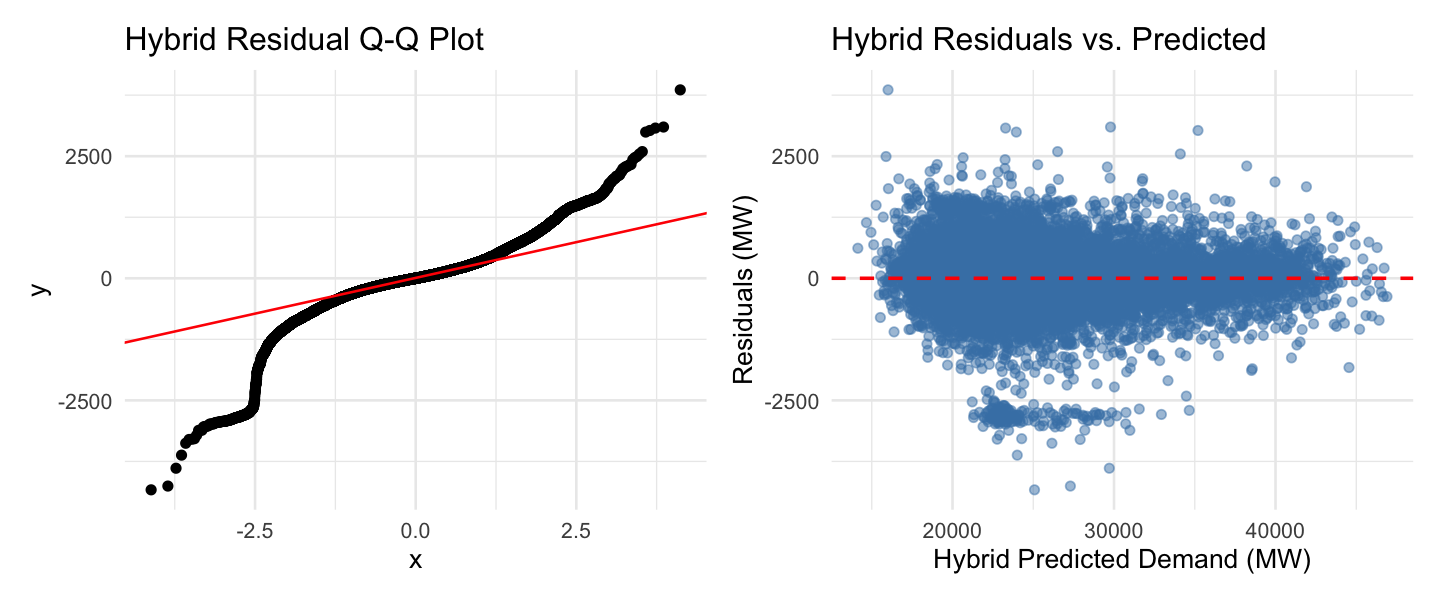

In [234]:
p1 <- ggplot(hybrid_train, aes(sample = hybrid_resid)) +
  stat_qq() + stat_qq_line(color = "red") +
  labs(title = "Hybrid Residual Q-Q Plot")

p2 <- ggplot(hybrid_train, aes(x = hybrid_pred, y = hybrid_resid)) +
  geom_point(alpha = 0.5, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
  labs(x = "Hybrid Predicted Demand (MW)", y = "Residuals (MW)",
       title = "Hybrid Residuals vs. Predicted")

options(repr.plot.width = 12, repr.plot.height = 5)
(p1 | p2)

The Q-Q plot is straighter through the middle than the OLS version, but the tails remain heavy, and the spread against predicted demand still widens. SARIMA addressed the correlation structure, not the extreme values or the non-constant variance. Addressing that would require a volatility model that accounts for heteroskedasticity.

<a id="sec43"></a>
### 4.3 Forecast evaluation on the held-out week

The two horizons require different forecasting procedures. At h = 1 the residual one step back is known, so the SARIMA model is applied with fixed coefficients to produce genuine one-step-ahead predictions. At h = 168 nothing is observed after the training set ends, so the model produces a true 168-step forecast.

In [235]:
# h = 1: one-step-ahead residual predictions, using observed residuals as they arrive
val_resid_lag <- dat_val %>%
  mutate(residuals = Electric_demand - pred_lag) %>%
  select(Time, residuals) %>% as_tsibble(index = Time)

sarima_1step <- augment(refit(sarima_lag, new_data = val_resid_lag, reestimate = FALSE))$.fitted

# h = 168: genuine multi-step forecast of the residuals
val_resid_new <- dat_val %>%
  select(Time) %>% mutate(residuals = NA_real_) %>% as_tsibble(index = Time)

sarima_168 <- as.numeric((sarima_nolag %>% forecast(new_data = val_resid_new) %>% as_tibble())$.mean)

dat_val <- dat_val %>%
  mutate(hybrid_1   = pred_lag   + sarima_1step,
         hybrid_168 = pred_nolag + sarima_168)

final_table <- rbind(
  "h = 1    Persistence (baseline)"    = metrics(actual, naive_persist),
  "h = 1    OLS + lag1"                = metrics(actual, dat_val$pred_lag),
  "h = 1    Hybrid (OLS + SARIMA)"     = metrics(actual, dat_val$hybrid_1),
  "h = 168  Seasonal naive (baseline)" = metrics(actual, snaive_168),
  "h = 168  OLS without lag"           = metrics(actual, dat_val$pred_nolag),
  "h = 168  Hybrid (OLS + SARIMA)"     = metrics(actual, dat_val$hybrid_168)
)
kable(final_table, digits = 2,
      caption = "All Models Against Their Baselines, Held-Out Week")



Table: All Models Against Their Baselines, Held-Out Week

|                                   |     MAE|    RMSE| MAPE|
|:----------------------------------|-------:|-------:|----:|
|h = 1    Persistence (baseline)    |  733.52|  919.03| 3.05|
|h = 1    OLS + lag1                |  440.26|  515.21| 1.88|
|h = 1    Hybrid (OLS + SARIMA)     |  110.47|  148.16| 0.46|
|h = 168  Seasonal naive (baseline) | 1197.15| 1581.49| 5.27|
|h = 168  OLS without lag           |  700.09|  907.65| 2.95|
|h = 168  Hybrid (OLS + SARIMA)     |  932.92| 1150.04| 3.85|

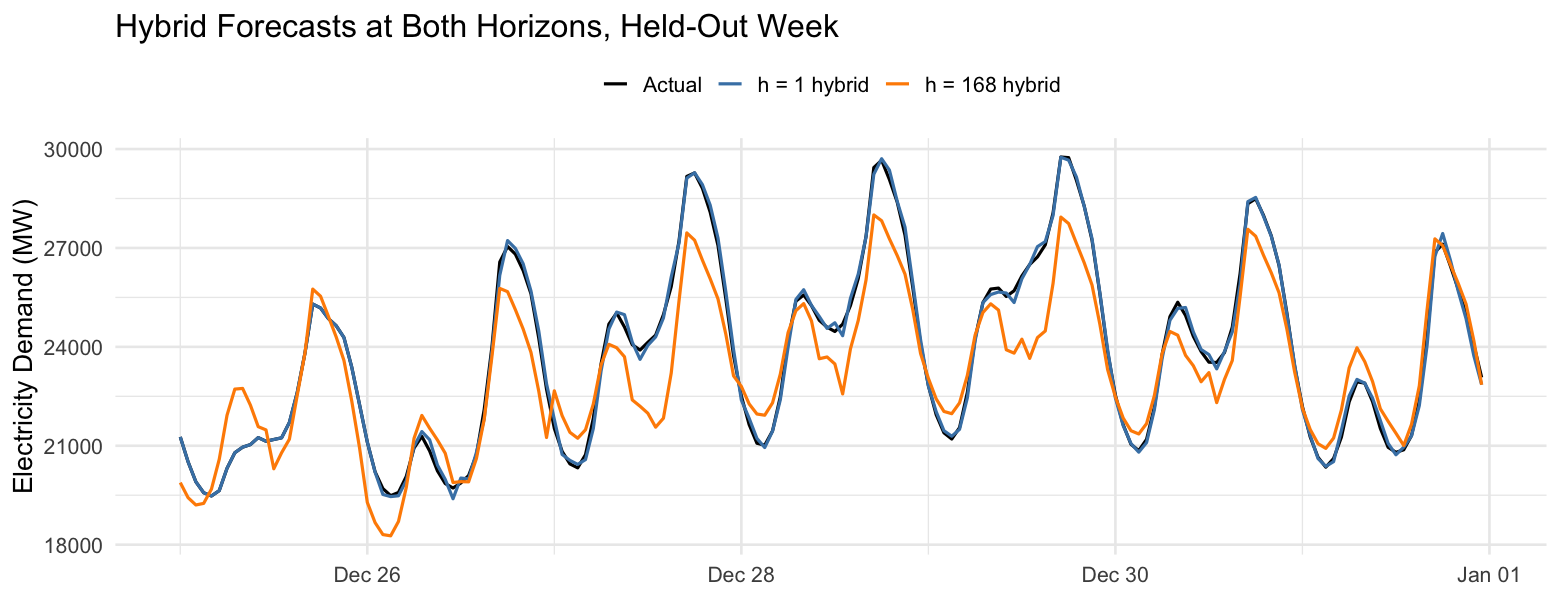

In [236]:
compare_long <- dat_val %>%
  as_tibble() %>%
  select(Time, Actual = Electric_demand,
         `h = 1 hybrid` = hybrid_1,
         `h = 168 hybrid` = hybrid_168) %>%
  pivot_longer(-Time, names_to = "series", values_to = "value")

options(repr.plot.width = 13, repr.plot.height = 5)
ggplot(compare_long, aes(x = Time, y = value, color = series)) +
  geom_line(linewidth = 0.9) +
  scale_color_manual(values = c("Actual" = "black",
                                "h = 1 hybrid" = "steelblue",
                                "h = 168 hybrid" = "darkorange")) +
  labs(title = "Hybrid Forecasts at Both Horizons, Held-Out Week",
       y = "Electricity Demand (MW)", x = NULL, color = NULL) +
  theme(legend.position = "top")

On the held-out week the residual model helps substantially at one hour ahead and hurts at one week ahead.

- At **h = 1**, the hybrid reaches 0.46% MAPE, against 1.88% for OLS alone and 3.05% for baseline. Adding the SARIMA stage removes about three quarters of the regression's remaining error. The reason is that at this horizon, the model is given the previous hour's residual, which is exactly the quantity its autoregressive terms are built to extrapolate. This figure also assumes temperature and irradiance at the target hour are known, which a forecaster working in real time would not have, so it is an upper bound on achievable accuracy rather than an operational result.

- At **h = 168**, the hybrid reaches 3.85%, worse than the 2.95% from OLS alone, though still better than the 5.27% baseline. Here the SARIMA stage has no recent residuals to work from: nothing is observed after the training set ends, so the entire forecast week is a 168-step extrapolation.

That ordering does not survive replication. Across the twelve rolling windows in Section 5 the hybrid beats OLS alone at this horizon in eight weeks of twelve, with a median of 4.18% against 5.38%. This week is the exception, and it is also the week on which the week-ahead regression performed best of the twelve, so the comparison here flatters OLS rather than exposing a flaw in the hybrid.

<a id="sec5"></a>
## 5. Rolling-origin validation

[Back to contents](#toc)

The test week for the forecast above is a single draw, and this one happens to be during Christmas holiday. Rolling-origin cross-validation refits the model at successive cutoffs and evaluates each following week, showing whether the results above are properties of the model or artifacts of the calendar.

This validation covers the baselines, the regression stage, and the SARIMA stage for the last 3 months in the dataset. Each fold refits the regressions and the SARIMA residual models on data up to the cutoff and forecasts the following week. The SARIMA orders are held at the values selected in Section 4.1, since a stepwise search per fold would be slow and the orders are stable; coefficients are re-estimated each time.

In [237]:
# Rolling-origin cross-validation across 12 consecutive test weeks.
RUN_CV  <- FALSE
cv_path <- "outputs/cv_results.rds"

# A residual series in the shape both SARIMA stages expect
as_resid <- function(times, r) tibble(Time = times, residuals = r) %>% as_tsibble(index = Time)

cv_fold <- function(k) {
  end_idx <- nrow(dat_ts_reg) - k * H
  val_k   <- dat_ts_reg[(end_idx - H + 1):end_idx, ]
  train_k <- dat_ts_reg[1:(end_idx - H), ]

  f_lag   <- Electric_demand ~ Temperature + I(Temperature^2) + GHI +
             Season + Day_of_the_week + hour_of_day + lag1_demand
  m_lag   <- lm(f_lag, data = train_k)
  m_nolag <- lm(update(f_lag, . ~ . - lag1_demand), data = train_k)
  p_lag   <- as.numeric(predict(m_lag,   newdata = val_k))
  p_nolag <- as.numeric(predict(m_nolag, newdata = val_k))

  # Orders fixed at the training-set selections in 4.1; coefficients refit per fold
  s_lag   <- as_resid(train_k$Time, residuals(m_lag))   %>%
             model(ARIMA(residuals ~ pdq(4,0,1) + PDQ(0,1,1, period = 24)))
  s_nolag <- as_resid(train_k$Time, residuals(m_nolag)) %>%
             model(ARIMA(residuals ~ pdq(2,0,2) + PDQ(2,1,0, period = 24)))

  # h = 1 sees each residual as it arrives; h = 168 forecasts the week blind
  hyb_1   <- p_lag + augment(refit(s_lag,
               new_data   = as_resid(val_k$Time, val_k$Electric_demand - p_lag),
               reestimate = FALSE))$.fitted
  hyb_168 <- p_nolag + as.numeric((s_nolag %>%
               forecast(new_data = as_resid(val_k$Time, NA_real_)) %>% as_tibble())$.mean)

  a    <- val_k$Electric_demand
  sn   <- dat_ts_reg$Electric_demand[(end_idx - H + 1 - 168):(end_idx - 168)]
  mape <- function(f) metrics(a, f)["MAPE"]

  tibble(week                   = format(min(val_k$Time), "%Y-%m-%d"),
         `h=1 persistence`      = mape(val_k$lag1_demand),
         `h=1 OLS+lag`          = mape(p_lag),
         `h=1 hybrid`           = mape(hyb_1),
         `h=168 seasonal naive` = mape(sn),
         `h=168 OLS no-lag`     = mape(p_nolag),
         `h=168 hybrid`         = mape(hyb_168))
}

if (RUN_CV) {
  cv_results <- map_dfr(0:11, cv_fold)
  saveRDS(cv_results, cv_path)
} else {
  cv_results <- readRDS(cv_path)
}

baselines <- c("h=1 OLS+lag"      = "h=1 persistence",
               "h=1 hybrid"       = "h=1 persistence",
               "h=168 OLS no-lag" = "h=168 seasonal naive",
               "h=168 hybrid"     = "h=168 seasonal naive")

cat("Weeks in which each model beats its naive baseline:\n")
for (m in names(baselines))
  cat(sprintf("  %-17s vs %-21s %2d of 12\n", m, baselines[m],
              sum(cv_results[[m]] < cv_results[[baselines[m]]])))

Weeks in which each model beats its naive baseline:
  h=1 OLS+lag       vs h=1 persistence       12 of 12
  h=1 hybrid        vs h=1 persistence       12 of 12
  h=168 OLS no-lag  vs h=168 seasonal naive   5 of 12
  h=168 hybrid      vs h=168 seasonal naive   7 of 12


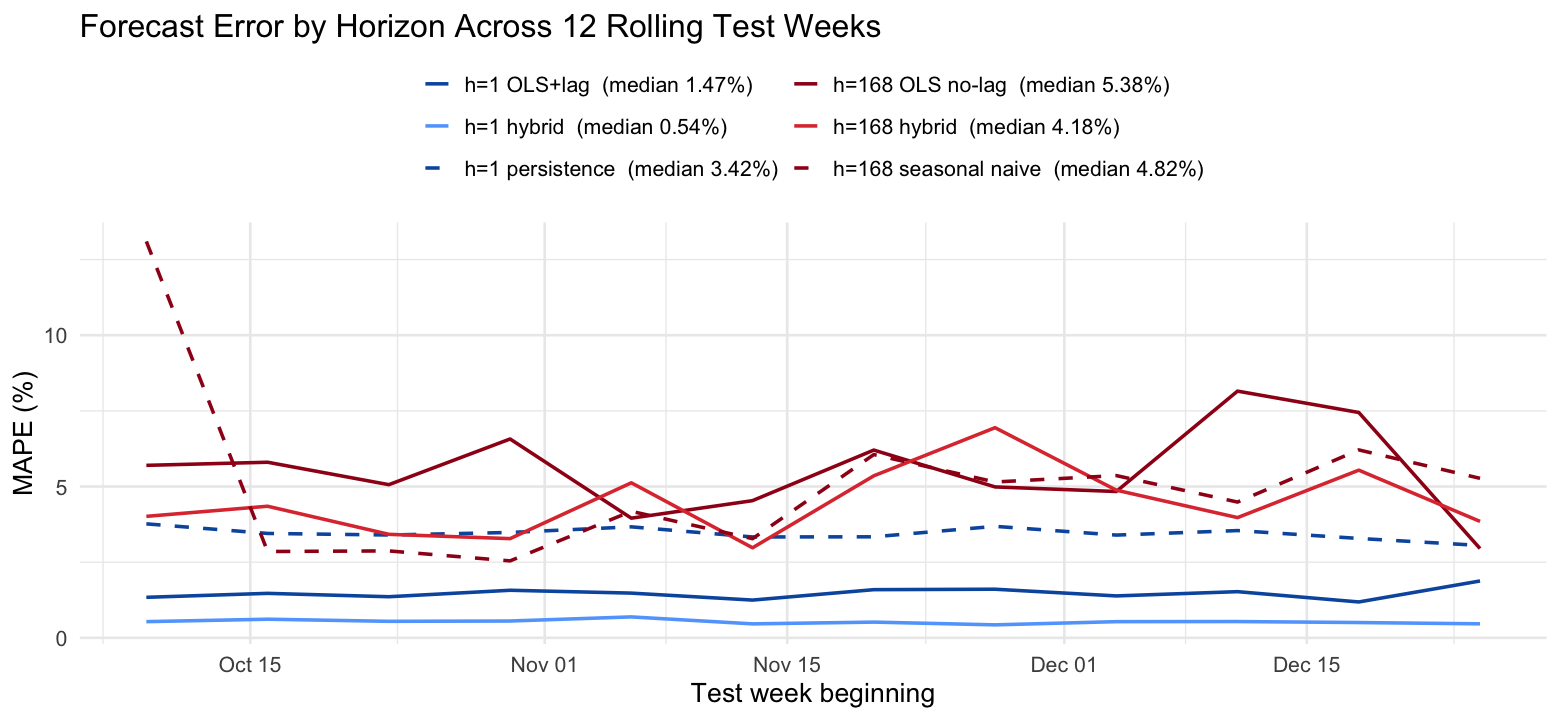

In [238]:
lv <- c("h=1 OLS+lag", "h=1 hybrid", "h=1 persistence",
        "h=168 OLS no-lag", "h=168 hybrid", "h=168 seasonal naive")

# Append each series median to its legend label
med_lab <- cv_results %>%
  summarize(across(where(is.numeric), median)) %>%
  pivot_longer(everything(), names_to = "approach", values_to = "med")
lab <- setNames(sprintf("%s  (median %.2f%%)", med_lab$approach, med_lab$med),
                med_lab$approach)

cv_long <- cv_results %>%
  pivot_longer(-week, names_to = "approach", values_to = "mape") %>%
  mutate(approach = factor(approach, levels = lv))

options(repr.plot.width = 13, repr.plot.height = 6)
ggplot(cv_long, aes(x = as.Date(week), y = mape, color = approach, linetype = approach)) +
  geom_line(linewidth = 1) +
  # Color marks the horizon, the lighter shade its hybrid; dashed marks the baseline
  scale_color_manual(values = c("h=1 OLS+lag"          = "#0759ac",
                                "h=1 hybrid"           = "#63a7fc",
                                "h=1 persistence"      = "#0759ac",
                                "h=168 OLS no-lag"     = "#9e0a1a",
                                "h=168 hybrid"         = "#de3b3d",
                                "h=168 seasonal naive" = "#9e0a1a"),
                     labels = lab) +
  scale_linetype_manual(values = c("h=1 OLS+lag"          = "solid",
                                   "h=1 hybrid"           = "solid",
                                   "h=1 persistence"      = "dashed",
                                   "h=168 OLS no-lag"     = "solid",
                                   "h=168 hybrid"         = "solid",
                                   "h=168 seasonal naive" = "dashed"),
                        labels = lab) +
  labs(title = "Forecast Error by Horizon Across 12 Rolling Test Weeks",
       x = "Test week beginning", y = "MAPE (%)", color = NULL, linetype = NULL) +
  theme(legend.position = "top") +
  guides(color = guide_legend(nrow = 3), linetype = guide_legend(nrow = 3))

The two horizons behave very differently once more than one week is examined.

- At **one hour ahead** the result is stable. The hybrid reaches 0.54% median MAPE against 3.42% for persistence and wins in all twelve weeks, with a worst week of 0.69%.

- At **one week ahead** the picture differs from what the single test week suggested. The hybrid reaches 4.18% median MAPE against 4.82% for the seasonal naive baseline, winning in seven of twelve weeks. The regression alone reaches 5.38%, worse than the baseline it is meant to beat, so the residual stage is what makes this horizon workable. The hybrid is also far more stable: its worst week is 6.94% against 13.10% for the naive forecast.

Taken together, the model has decisive skill one hour ahead and modest skill one week ahead. Section 4.3 judged the residual stage on the Christmas week alone and concluded it hurt at a week ahead; twelve windows reverse that, which is the argument for rolling origins over a single split.

<a id="sec6"></a>
## 6. Conclusions

[Back to contents](#toc)

I fit a hybrid forecast combining OLS on weather and calendar variables with a SARIMA model of the residuals, and evaluated it at two horizons against naive baselines, on one held-out week and across twelve rolling windows.

| Horizon | Best approach | Median MAPE | Baseline | Beats baseline |
|---|---|---|---|---|
| 1 hour ahead | Hybrid OLS + SARIMA | 0.54% | 3.42% persistence | 12 of 12 weeks |
| 1 week ahead | Hybrid OLS + SARIMA | 4.18% | 4.82% seasonal naive | 7 of 12 weeks |

The model beats its baseline at both horizons, but by very different margins. 
- **One hour ahead** it is decisive: 0.54% median MAPE against 3.42% for persistence, winning every week, with a worst week of 0.69%. 
- **One week ahead** the margin is thin, 4.18% against 4.82%, and it wins in only seven of twelve weeks. OLS alone reaches 5.38%, worse than the baseline it is meant to beat, so the residual stage is the only reason a week-ahead model is worth fitting at all. The hybrid is also more stable; its worst week is 6.94% against 13.10% for the naive forecast.

Underneath both results is that `lag1_demand` raises R² from 0.844 to 0.992 while contributing nothing usable beyond the first hour. More generally, the horizon and the test window are evaluation choices that change the takeaways from the model. Judging the SARIMA stage on the single held-out week would have discarded the stability component that makes the week-ahead forecast work.

Apart from forecasting performance, the OLS stage enables these insights:

- Irradiance is negatively associated with measured demand once temperature is held fixed, which reflects the replacement of grid-drawn electricity with solar generated on site, not a reduction in underlying consumption.
- Hour-of-day effects span 7,873 MW after weather is controlled for, so much of the daily swing is behavioral.
- The steepest hour-to-hour increase in average demand occurs in winter, not summer, despite summer having the higher peak.

### Limitations

- The two stages are fitted sequentially, so the standard errors in 3.1 do not account for the SARIMA step. 
    - I kept the two stages because at h = 1 the lagged demand term and the AR terms compete to explain the same persistence, and because a joint fit over 35 regressors and 26,000 hours is slow and prone to non-convergence.
- Heteroskedasticity is unaddressed, so confidence intervals are too narrow at high demand where they matter most. This is illustrated by the heavy tails in the Q-Q plots.
- Both models use observed temperature and irradiance for the test period as a proxy for available weather forecasts. However, a genuine week-ahead forecast would have to use actual forecasted weather and carry error the figures above do not include, so the week-ahead results are optimistic.
- I treat the 2020 elevation in summer demand as ordinary variation and do not model it.
- I select the SARIMA orders once on the full training period and reuse them in every fold, so a fold's orders were chosen with data from its own test week. The leak is slight, but it makes the rolling results a little optimistic.
- The rolling-origin windows all fall in the last quarter of 2021, so they test the model's skill for week-to-week variation but not seasonal variation.
- The conclusions don't generalize to other regions.

### Next steps

- Refit regression with ARIMA errors (i.e. ARIMAX) for valid standard errors.
- Add holiday and COVID-19 indicators so atypical weeks stop distorting week-ahead accuracy.
- Extend the rolling-origin windows across a full year so that week-ahead skill can be assessed in summer as well as fall.
- Replace observed weather with lagged weather forecasts for a realistic operational assessment.

<a id="refs"></a>
## References

[Back to contents](#toc)

Rojas Ortega, Sebastian; Castro-Correa, Paola; Sepúlveda-Mora, Sergio; Castro-Correa, Jhon (2023). "Renewable Energy and Electricity Demand Time Series Dataset with Exogenous Variables at 5-minute Interval." Mendeley Data, V1. doi: [10.17632/fdfftr3tc2.1](https://doi.org/10.17632/fdfftr3tc2.1)

Hyndman, R.J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd edition, OTexts. Source for the rolling-origin validation and naive-baseline conventions.